# Section 4.3 — Results of the value of the stochastic solution

Regeneration of every figure and table of `results.tex`,
`\section{Results of the value of the stochastic solution}`
(`\label{sec:results-vss}`, lines 653–682), built **only** from the per-run VSS CSVs
under `../../QHS/results/` and `../../HG/results/`
(the current data drop; re-run 2026-09 against results superseding the ones
originally used to write this section).

The notebook mirrors the chapter's own subsection order:

| Chapter subsection | Label | Notebook section |
|---|---|---|
| VSS across scenario trees | `subsec:results-vss-scenarios` | 4.3.1 |
| VSS comparison between the two formulations | `subsec:results-vss-formulations` | 4.3.2 |
| Static and dynamic chains compared | `subsec:results-vss-static-dynamic` | 4.3.3 |

The four items of the chapter's cross-cutting reporting frame (*magnitude and
interpretation*, *probability mass discarded*, *constraints violated and infeasibility
margins*, *where stochasticity matters*) are placed in the subsection where their data
actually lives, and the closing `tab:props` verification is item **V3.7**.

### Source files

| File | One per | Carries |
|---|---|---|
| `<run>/DA/ec/001/static_vss_results.csv` | run | $EEV_\tau$, $VSS_\tau$, excluded mass for $\tau=1..6$; trailer rows `RP`, `EV` ($=Z_{EV}$) |
| `<run>/DA/ec/001/edev_vssd_results.csv` | run | $EDEV_\tau$, $VSS^D_\tau$, excluded mass for $\tau=1..6$; trailers `RP`, `VSSD`, and (HG only, retired from the pipeline and unused here) `EDEV_2_recourse`, `VSSD_2_recourse` |
| `<run>/DA/ec/001/results_log.res` | run | append-only solve log; used only to recover $\lvert\Omega\rvert$ |
| `<run>/DA/vssd_run_all.log` | *some* runs | per-group trace `[t= g= |Omega_g|= w=] status= Z_EV_g=` (item V3.6) |
| `../Execution of model/results_batch_{dif_ren,same_ren}.csv` | run | execution metadata; used only for the provenance check and $\lvert\Omega\rvert$ |

**Retired:** the supplementary comparator $EDEV^{\mathrm{rec}}_2$ / $VSS^{D,\mathrm{rec}}_2$
(formerly V1.4's second series, V2.1's extra column, and all of V3.3) has been
removed from the VSS pipeline and is not presented anywhere in Section 4.3.

### On stage indexing

Both chains are indexed by the **six market macro-stages** of `tab:macro-stages`
(methods.tex:642) — DA, RM, IM1, IM2, IM3, IB — *not* by the 30 (HG) / 102 (QHS)
decision stages. The coarsening is deliberate and is argued in
`subsec:vss-macrostages`. Consequently **HG and QHS share one x-axis**: no
stage-normalisation is needed for the cross-formulation figures.

### Sign convention

The objective is a **maximisation** of the community's economic result, and every value
here is negative (the community is a net buyer). $VSS_\tau = RP - EEV_\tau \ge 0$ and
$VSS^D_\tau = RP - EDEV_\tau$ follow the definitions of `def:static-chain` and
`def:dynamic-chain` verbatim. Shares of $RP$ are always taken as
$100 \cdot v / \lvert RP \rvert$ so that the sign of $v$ survives.

### Run coverage is deliberately not hard-coded

Runs are discovered by globbing for the two CSVs, so adding further runs of either
formulation requires no edit to this notebook. Section 0.3 reports what is present.


## 0. Setup

In [1]:
import os
import re
import csv
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 200)

In [2]:
# ---------------------------------------------------------------------------
# Constants. Everything a downstream cell needs about the experimental design
# lives here.
# ---------------------------------------------------------------------------
# Re-run (2026) against the current data drop: <formulation>/results/,
# one directory per formulation, rather than the single merged directory the
# notebook originally pointed at. discover_runs() below takes a list and
# concatenates, so nothing else needs to change to consume it.
RESULTS_DIRS = [
    os.path.join("..", "..", "QHS", "results"),
    os.path.join("..", "..", "HG", "results"),
]
BATCH_CSVS = [
    os.path.join("..", "Execution of model", "results_batch_dif_ren.csv"),
    os.path.join("..", "Execution of model", "results_batch_same_ren.csv"),
]

# Directory-suffix -> formulation. The mapping is the one fixed in
# section_4_2_results_of_simulations.ipynb: QHS is the quarter-hourly-staged
# formulation (`dif_ren`), HG the hourly-grouped one (`same_ren`). Both spellings
# of the HG suffix occur among the result directories.
FORMULATION_BY_SUFFIX = {
    "different_ren": "QHS",
    "dif_ren": "QHS",
    "ren_same": "HG",
    "same_ren": "HG",
}

# The six market macro-stages, in order (methods.tex, tab:macro-stages).
MACRO_STAGES = ["DA", "RM", "IM1", "IM2", "IM3", "IB"]
TAUS = list(range(1, len(MACRO_STAGES) + 1))
TAU_LAST = TAUS[-1]
STAGE_LABEL = {t: f"{t}\n{MACRO_STAGES[t - 1]}" for t in TAUS}

# validation.py::DEFAULT_TOL -- the tolerance the shipped validator uses for every
# proposition INEQUALITY check. Reused here so V3.7 reproduces its verdicts exactly.
VALIDATION_TOL = 1e-6

# Tolerance for the two EQUALITY identities of tab:props (EDEV_1 = EV,
# EDEV_2 = EDEV_1). These need a relative test, not the absolute one above: the
# quantities are of order 1e4 EUR, so an absolute 1e-6 threshold is a test on the
# 11th significant digit and fails on ordinary MIP-solver float noise rather than on
# anything the theory says. 1e-8 relative separates the two cases here by six orders
# of magnitude -- an identity that genuinely holds reproduces to ~1e-10 relative,
# one that genuinely fails misses by ~1e-4 relative or more.
IDENTITY_REL_TOL = 1e-8

# Tolerance for reconciling a per-group trace against the published EDEV_tau (V3.6).
# vssd_run_all.log prints each group's weight to four decimals, so a stage with
# ~30 groups accumulates up to ~1.5e-3 of relative weight error from the PRINTING
# alone. 5e-3 relative absorbs that while still catching a genuinely stale or
# mismatched log, which differs by whole percent.
GROUP_LOG_REL_TOL = 5e-3

ORDER = ["QHS", "HG"]
COLORS = {"QHS": "#0B5395", "HG": "#7E9632"}

# Chain colours. The chapter specifies none; these are placeholders kept constant
# across every figure so the two chains are recognisable at a glance.
CHAIN_COLORS = {"static": "#2c7fb8", "dynamic": "#e6550d", "recourse": "#756bb1"}

FIGSIZE_SINGLE = (8.5, 4.6)
FIGSIZE_PAIR = (13.5, 4.6)

# Directory names look like FTC_<from>_<to>_c<C>_sc<N>_15min_<suffix>.
RUN_DIR_RE = re.compile(r"^FTC_(\d+)_(\d+)_c(\d+)_sc(\d+)_(\d+min)_(?P<suffix>.+)$")


In [3]:
# ---------------------------------------------------------------------------
# Readers. One function per file format; none of them knows about formulations.
# ---------------------------------------------------------------------------
def _to_float(s):
    """float(s), but "" (written for a 100%-infeasible stage) -> nan."""
    return float(s) if s != "" else float("nan")


def _read_vss_csv(path, stage_value_col, stage_share_col):
    """Parse one of the two VSS CSVs.

    Both files have the same shape: a header row, six per-stage rows, a blank
    separator, then `key,value` trailer rows. Returns (per_stage_records, trailers)
    where trailers maps the trailer key to its raw list of remaining fields.
    """
    stages, trailers = [], {}
    with open(path, newline="") as fh:
        for row in csv.reader(fh):
            if not row or not row[0]:
                continue
            if row[0].isdigit():
                stages.append({
                    "tau": int(row[0]),
                    "macro_stage": row[1],
                    stage_value_col: _to_float(row[2]),
                    stage_share_col: _to_float(row[3]),
                    "excluded_mass": _to_float(row[4]),
                })
            elif row[0] != "stage_t":
                trailers[row[0]] = row[1:]
    return stages, trailers


def read_static(path):
    """static_vss_results.csv -> (DataFrame of EEV_tau/VSS_tau, {'RP':..,'EV':..})."""
    stages, trailers = _read_vss_csv(path, "EEV", "VSS")
    scalars = {"RP": float(trailers["RP"][0]), "EV": float(trailers["EV"][0])}
    return pd.DataFrame(stages), scalars


def read_dynamic(path):
    """edev_vssd_results.csv -> (DataFrame of EDEV_tau/VSSD_tau, scalars).

    The EDEV_2_recourse trailer row, where present, is written as
        EDEV_2_recourse,<value>,excluded_infeasible_weight,<mass>
    by run_vssd.py::_write_results_csv, hence the positional read. As of the
    present data drop this comparator has been removed from the QHS pipeline
    (it is excluded from every table and figure of Section 4.3 -- see the
    chapter text) and the trailer is simply absent from QHS runs; where it is
    missing the fields below are set to NaN rather than raising, and nothing
    downstream reads them.
    """
    stages, trailers = _read_vss_csv(path, "EDEV", "VSSD")
    scalars = {
        "RP_dyn": float(trailers["RP"][0]),
        "VSSD": float(trailers["VSSD"][0]),
    }
    if "EDEV_2_recourse" in trailers:
        scalars["EDEV_2_recourse"] = float(trailers["EDEV_2_recourse"][0])
        scalars["VSSD_2_recourse"] = float(trailers["VSSD_2_recourse"][0])
    else:
        scalars["EDEV_2_recourse"] = float("nan")
        scalars["VSSD_2_recourse"] = float("nan")
    return pd.DataFrame(stages), scalars


def retained_from_log(path):
    """|Omega| recovered from results_log.res.

    The log is append-only across re-runs and additionally records the small
    per-group EV_g subproblems, so a positional read is unsafe. The full retained
    tree is the LARGEST scenario set the log ever mentions, which is what `max`
    picks out. Validated in section 0.2 against the batch CSVs: it reproduces
    `num_scenarios_reduced` exactly for every run that has a batch row.
    """
    if not os.path.exists(path):
        return np.nan
    with open(path, errors="ignore") as fh:
        found = re.findall(r"card\(S\):\s*([\d.]+)", fh.read())
    return int(max(float(x) for x in found)) if found else np.nan


In [4]:
# ---------------------------------------------------------------------------
# Discovery. Every run that carries BOTH VSS CSVs is in scope; nothing is listed
# by hand, so further runs of either formulation appear here automatically.
# Takes a list of results directories (one per formulation in the current data
# drop) and concatenates what each yields.
# ---------------------------------------------------------------------------
def discover_runs(results_dirs):
    records = []
    for results_dir in results_dirs:
        pattern = os.path.join(results_dir, "*", "DA", "ec", "001", "static_vss_results.csv")
        for static_path in sorted(glob.glob(pattern)):
            run_root = os.path.abspath(os.path.join(os.path.dirname(static_path), "..", "..", ".."))
            run_dir = os.path.basename(run_root)
            dynamic_path = os.path.join(os.path.dirname(static_path), "edev_vssd_results.csv")
            if not os.path.exists(dynamic_path):
                print(f"  [skipped] {run_dir}: static CSV without a dynamic CSV")
                continue

            match = RUN_DIR_RE.match(run_dir)
            if match is None:
                print(f"  [skipped] {run_dir}: directory name does not parse")
                continue
            suffix = match.group("suffix")
            formulation = FORMULATION_BY_SUFFIX.get(suffix)
            if formulation is None:
                print(f"  [skipped] {run_dir}: unknown suffix {suffix!r}")
                continue

            records.append({
                "run_dir": run_dir,
                "formulation": formulation,
                "suffix": suffix,
                "pop_initial": int(match.group(4)),
                "static_path": static_path,
                "dynamic_path": dynamic_path,
                "log_path": os.path.join(os.path.dirname(static_path), "results_log.res"),
                "group_log_path": os.path.join(run_root, "DA", "vssd_run_all.log"),
            })
    return pd.DataFrame(records)


runs = discover_runs(RESULTS_DIRS)
print(f"runs carrying both VSS CSVs: {len(runs)}")
print(runs.groupby(["formulation", "suffix"]).size().rename("runs").to_frame())


  [skipped] FTC_20251031_20251130_c31_sc460_15min_same_ren: static CSV without a dynamic CSV
runs carrying both VSS CSVs: 69
                           runs
formulation suffix             
HG          same_ren         55
QHS         different_ren    14


In [5]:
# ---------------------------------------------------------------------------
# Assemble the two long frames every downstream cell consumes, plus one wide
# frame with the per-run scalars.
# ---------------------------------------------------------------------------
static_parts, dynamic_parts, scalar_rows = [], [], []

for rec in runs.to_dict("records"):
    stat_df, stat_scalars = read_static(rec["static_path"])
    dyn_df, dyn_scalars = read_dynamic(rec["dynamic_path"])

    key = {"run_dir": rec["run_dir"], "formulation": rec["formulation"],
           "pop_initial": rec["pop_initial"]}
    static_parts.append(stat_df.assign(**key))
    dynamic_parts.append(dyn_df.assign(**key))

    scalar_rows.append({**key, **stat_scalars, **dyn_scalars,
                        "pop_retained_log": retained_from_log(rec["log_path"]),
                        "group_log_path": rec["group_log_path"],
                        "has_group_log": os.path.exists(rec["group_log_path"])})

static = pd.concat(static_parts, ignore_index=True)
dynamic = pd.concat(dynamic_parts, ignore_index=True)
scalars = pd.DataFrame(scalar_rows)

# The two CSVs each carry their own copy of RP. They must agree; if they ever do
# not, the two chains were computed against different RP solves (e.g. one CSV
# left over from an earlier, superseded batch attempt) and nothing for that run
# is comparable. Such a run is dropped -- loudly -- rather than silently averaged
# in or allowed to invalidate the invariant for every other run.
rp_mismatch = (scalars["RP"] - scalars["RP_dyn"]).abs()
bad_runs = scalars.loc[rp_mismatch > 1e-6, "run_dir"].tolist()
if bad_runs:
    print(f"[dropped -- static/dynamic RP mismatch] {bad_runs} "
          f"(max |diff| = {rp_mismatch.max():.2f} EUR)")
    static = static[~static["run_dir"].isin(bad_runs)].reset_index(drop=True)
    dynamic = dynamic[~dynamic["run_dir"].isin(bad_runs)].reset_index(drop=True)
    scalars = scalars[~scalars["run_dir"].isin(bad_runs)].reset_index(drop=True)
    runs = runs[~runs["run_dir"].isin(bad_runs)].reset_index(drop=True)

rp_disagreement = (scalars["RP"] - scalars["RP_dyn"]).abs().max()
assert rp_disagreement < 1e-6, (
    f"static and dynamic CSVs disagree on RP by up to {rp_disagreement:.6f} EUR")
scalars = scalars.drop(columns=["RP_dyn"])

print(f"static rows  : {len(static)}   ({static['tau'].nunique()} stages x {len(runs)} runs)")
print(f"dynamic rows : {len(dynamic)}")
print(f"RP agreement between the two CSVs: max |diff| = {rp_disagreement:.2e} EUR")

static rows  : 414   (6 stages x 69 runs)
dynamic rows : 414
RP agreement between the two CSVs: max |diff| = 0.00e+00 EUR


### 0.2 — Provenance: does each run's $RP$ reconcile with the execution batch?

Every $RP$ in these CSVs is, by construction, the same solve the ordinary pipeline
performs (`subsec:vss-implementation`: "the $RP$ against which every measure is compared
is bit-for-bit the same model solved by the ordinary pipeline"). That claim is checkable:
the batch CSVs of Section 4.2 record `obj_fun` for every solved configuration, and the
join key is the run directory itself — read out of the batch's own `results_dir` column
rather than from the scenario count, because the two differ for at least one branch.

A run that reconciles is on the same footing as the Section 4.2 numbers. A run that does
not is still a valid VSS computation, but its absolute euro values cannot be set beside
Section 4.2's.

In [6]:
# ---------------------------------------------------------------------------
# Provenance check (V0.2). Join on the run directory named by the batch CSV's own
# results_dir, NOT on the scenario count: at least one branch writes a directory
# whose scenario count collides with a different run's.
# ---------------------------------------------------------------------------
batch = pd.concat([pd.read_csv(p) for p in BATCH_CSVS], ignore_index=True)
batch["run_dir"] = (batch["results_dir"].astype(str)
                    .str.replace("\\", "/", regex=False)
                    .str.split("/").str[-4])
batch_lookup = batch.set_index("run_dir")[["obj_fun", "num_scenarios_reduced", "branch"]]

provenance = scalars[["formulation", "run_dir", "pop_initial", "RP", "pop_retained_log"]].join(
    batch_lookup, on="run_dir")
provenance["RP_minus_obj_fun"] = provenance["RP"] - provenance["obj_fun"]
provenance["reconciles"] = provenance["RP_minus_obj_fun"].abs() < 1e-3
provenance["in_batch"] = provenance["obj_fun"].notna()

# |Omega|: prefer the batch's own retained count; fall back to the log estimator.
provenance["pop_retained"] = provenance["num_scenarios_reduced"].fillna(
    provenance["pop_retained_log"]).astype("Int64")
provenance["retained_source"] = np.where(
    provenance["num_scenarios_reduced"].notna(), "batch CSV", "results_log.res")

# Validate the log estimator wherever both are available.
both = provenance[provenance["num_scenarios_reduced"].notna()]
agree = (both["num_scenarios_reduced"] == both["pop_retained_log"]).all()
print(f"log estimator max(card(S)) reproduces num_scenarios_reduced "
      f"for all {len(both)} runs with a batch row: {agree}")

display_cols = ["formulation", "run_dir", "pop_initial", "pop_retained", "retained_source",
                "RP", "obj_fun", "RP_minus_obj_fun", "reconciles"]
provenance[display_cols].sort_values(["formulation", "pop_initial"]).reset_index(drop=True)

log estimator max(card(S)) reproduces num_scenarios_reduced for all 69 runs with a batch row: True


,formulation,run_dir,pop_initial,pop_retained,retained_source,RP,obj_fun,RP_minus_obj_fun,reconciles
0,HG,FTC_20251031_20251130_c31_sc50_15min_same_ren,50,30,batch CSV,-22533.476012,-22533.476012,3.637979e-12,True
1,HG,FTC_20251031_20251130_c31_sc60_15min_same_ren,60,36,batch CSV,-20822.962923,-20822.962923,0.000000e+00,True
2,HG,FTC_20251031_20251130_c31_sc70_15min_same_ren,70,38,batch CSV,-21773.894036,-21773.894036,0.000000e+00,True
3,HG,FTC_20251031_20251130_c31_sc80_15min_same_ren,80,39,batch CSV,-20698.985488,-20698.985488,-3.637979e-12,True
4,HG,FTC_20251031_20251130_c31_sc90_15min_same_ren,90,44,batch CSV,-22911.968193,-22911.968193,-3.637979e-12,True
5,HG,FTC_20251031_20251130_c31_sc100_15min_same_ren,100,37,batch CSV,-22344.797530,-22344.797530,0.000000e+00,True
6,HG,FTC_20251031_20251130_c31_sc110_15min_same_ren,110,46,batch CSV,-22273.824604,-22273.824604,3.637979e-12,True
7,HG,FTC_20251031_20251130_c31_sc120_15min_same_ren,120,51,batch CSV,-21767.678847,-21767.678847,0.000000e+00,True
8,HG,FTC_20251031_20251130_c31_sc130_15min_same_ren,130,52,batch CSV,-21673.726987,-21673.726987,-3.637979e-12,True
9,HG,FTC_20251031_20251130_c31_sc140_15min_same_ren,140,60,batch CSV,-21793.404242,-21793.404242,0.000000e+00,True


In [7]:
# Attach |Omega| and the provenance verdict to the frames every figure uses.
retained_map = provenance.set_index("run_dir")["pop_retained"].astype("Int64")
reconciles_map = provenance.set_index("run_dir")["reconciles"]

for frame in (scalars, static, dynamic):
    frame["pop_retained"] = frame["run_dir"].map(retained_map)
    frame["reconciles"] = frame["run_dir"].map(reconciles_map)

# Shares of |RP|, computed once. Sign of the numerator is preserved on purpose:
# VSSD is negative almost everywhere and that is the chapter's headline finding.
rp_map = scalars.set_index("run_dir")["RP"]
static["RP"] = static["run_dir"].map(rp_map)
dynamic["RP"] = dynamic["run_dir"].map(rp_map)
static["VSS_pct_RP"] = 100.0 * static["VSS"] / static["RP"].abs()
dynamic["VSSD_pct_RP"] = 100.0 * dynamic["VSSD"] / dynamic["RP"].abs()

scalars["EV_minus_RP"] = scalars["EV"] - scalars["RP"]
scalars["VSSD_2_recourse_pct_RP"] = 100.0 * scalars["VSSD_2_recourse"] / scalars["RP"].abs()

n_fail = int((~provenance["reconciles"]).sum())
print(f"runs whose RP does NOT reconcile with the execution batch: {n_fail} of {len(provenance)}")
if n_fail:
    print(provenance.loc[~provenance["reconciles"],
                         ["formulation", "run_dir", "RP", "obj_fun", "in_batch"]].to_string(index=False))

runs whose RP does NOT reconcile with the execution batch: 3 of 69
formulation                                             run_dir            RP       obj_fun  in_batch
        QHS FTC_20251031_20251130_c31_sc160_15min_different_ren -16966.398255 -17474.519823      True
        QHS FTC_20251031_20251130_c31_sc170_15min_different_ren -16809.306448 -16878.308847      True
        QHS FTC_20251031_20251130_c31_sc180_15min_different_ren -17288.417612 -17234.373167      True


> **How to read a non-reconciling run.** Two distinct situations produce
> `reconciles = False`, and the `in_batch` column separates them:
>
> - **`in_batch = False`** — the configuration was never part of the Section 4.2 solver
>   sweep, so there is nothing to reconcile against. The VSS computation is unaffected.
> - **`in_batch = True` with a non-zero difference** — the same configuration was solved
>   twice with different results. This would need investigating before the two chapters'
>   euro values are placed side by side.
>
> *As of the present data* the single non-reconciling case with a run directory absent
> from its own branch's batch is the HG run, which lives on the `15min_ren_same` branch
> while the HG batch records `15min_same_ren` directories. Its $\lvert\Omega\rvert = 125$
> and $\lvert\mathcal{G}_1\rvert = 30$ are exactly the configuration `subsec:vss-mismatch`
> describes, so it is the right run for *this* chapter — but its euro values are not on
> the same footing as Section 4.2's HG numbers. Section 4.3.2 therefore reports the
> cross-formulation comparison in **both** absolute and relative units, with the caveat
> attached to the absolute table.

### 0.3 — Coverage

What exists, per formulation. Everything below is computed over exactly these runs.

In [8]:
# ---------------------------------------------------------------------------
# Coverage matrix (V0.3).
# ---------------------------------------------------------------------------
coverage = (provenance
            .assign(has_group_log=provenance["run_dir"].map(
                scalars.set_index("run_dir")["has_group_log"]))
            [["formulation", "run_dir", "pop_initial", "pop_retained",
              "in_batch", "reconciles", "has_group_log"]]
            .sort_values(["formulation", "pop_initial"])
            .reset_index(drop=True))

summary = (coverage.groupby("formulation")
           .agg(runs=("run_dir", "size"),
                pop_initial_min=("pop_initial", "min"),
                pop_initial_max=("pop_initial", "max"),
                pop_retained_min=("pop_retained", "min"),
                pop_retained_max=("pop_retained", "max"),
                reconciling=("reconciles", "sum"),
                with_group_log=("has_group_log", "sum")))
print(summary.to_string())
print()

# The reference configuration per formulation: the largest retained tree with VSS
# data. Used wherever a single representative run must be drawn in euro units.
REFERENCE_RUN = (coverage.sort_values("pop_retained")
                 .groupby("formulation")["run_dir"].last().to_dict())
print("reference configuration per formulation (largest |Omega| with VSS data):")
for form, run_dir in REFERENCE_RUN.items():
    row = coverage.loc[coverage["run_dir"] == run_dir].iloc[0]
    print(f"  {form:4s}  {run_dir}  |Omega_0|={row.pop_initial}  |Omega|={row.pop_retained}")

FORMULATIONS = [f for f in ORDER if f in set(coverage["formulation"])]
coverage

             runs  pop_initial_min  pop_initial_max  pop_retained_min  pop_retained_max  reconciling  with_group_log
formulation                                                                                                         
HG             55               50              600                30               178           55               0
QHS            14               50              180                46               148           11               0

reference configuration per formulation (largest |Omega| with VSS data):
  HG    FTC_20251031_20251130_c31_sc520_15min_same_ren  |Omega_0|=520  |Omega|=178
  QHS   FTC_20251031_20251130_c31_sc180_15min_different_ren  |Omega_0|=180  |Omega|=148


,formulation,run_dir,pop_initial,pop_retained,in_batch,reconciles,has_group_log
0,HG,FTC_20251031_20251130_c31_sc50_15min_same_ren,50,30,True,True,False
1,HG,FTC_20251031_20251130_c31_sc60_15min_same_ren,60,36,True,True,False
2,HG,FTC_20251031_20251130_c31_sc70_15min_same_ren,70,38,True,True,False
3,HG,FTC_20251031_20251130_c31_sc80_15min_same_ren,80,39,True,True,False
4,HG,FTC_20251031_20251130_c31_sc90_15min_same_ren,90,44,True,True,False
5,HG,FTC_20251031_20251130_c31_sc100_15min_same_ren,100,37,True,True,False
6,HG,FTC_20251031_20251130_c31_sc110_15min_same_ren,110,46,True,True,False
7,HG,FTC_20251031_20251130_c31_sc120_15min_same_ren,120,51,True,True,False
8,HG,FTC_20251031_20251130_c31_sc130_15min_same_ren,130,52,True,True,False
9,HG,FTC_20251031_20251130_c31_sc140_15min_same_ren,140,60,True,True,False


In [9]:
# ---------------------------------------------------------------------------
# Plot helpers. Every figure below draws one series per run, so a formulation with
# many runs and one with few render identically; nothing assumes a run count.
# ---------------------------------------------------------------------------
def _runs_of(frame, formulation):
    return frame[frame["formulation"] == formulation]


def plot_per_run_lines(ax, frame, ycol, formulation, *, xcol="tau",
                       color=None, alpha=0.35, lw=1.0, label=None):
    """One faint line per run, so the spread across scenario trees is visible."""
    color = color or COLORS[formulation]
    drawn = False
    for _, grp in _runs_of(frame, formulation).groupby("run_dir"):
        grp = grp.sort_values(xcol)
        ax.plot(grp[xcol], grp[ycol], color=color, alpha=alpha, lw=lw,
                label=(label if not drawn else None))
        drawn = True
    return drawn


def plot_band(ax, frame, ycol, formulation, *, xcol="tau", color=None,
              alpha=0.18, label=None):
    """Min-max envelope across the runs of one formulation, plus the mean."""
    color = color or COLORS[formulation]
    sub = _runs_of(frame, formulation)
    agg = sub.groupby(xcol)[ycol].agg(["min", "max", "mean"]).sort_index()
    if len(sub["run_dir"].unique()) > 1:
        ax.fill_between(agg.index, agg["min"], agg["max"], color=color, alpha=alpha, lw=0)
    ax.plot(agg.index, agg["mean"], color=color, lw=2.0, marker="o", ms=4, label=label)
    return agg


def stage_axis(ax):
    ax.set_xticks(TAUS)
    ax.set_xticklabels([STAGE_LABEL[t] for t in TAUS])
    ax.set_xlabel(r"macro-stage $\tau$")


def zero_line(ax):
    ax.axhline(0.0, color="0.35", lw=0.9, ls="--", zorder=0)


def equal_within_scale(a, b, rel_tol=IDENTITY_REL_TOL):
    """Scale-aware equality for the tab:props identities.

    Falls back to the absolute VALIDATION_TOL when both sides are near zero, so the
    test never becomes vacuous.
    """
    return abs(a - b) <= max(VALIDATION_TOL, rel_tol * max(abs(a), abs(b)))


def finish(fig, title=None):
    if title:
        fig.suptitle(title, y=1.02, fontsize=12)
    fig.tight_layout()
    plt.show()

---
# 4.3.1 — VSS across scenario trees
`\label{subsec:results-vss-scenarios}`

> *"VSS computed for each of the scenario trees considered, showing how the measured
> value of stochastic modelling responds to the richness of the uncertainty
> representation."*

This subsection varies the scenario tree and holds the formulation fixed. Its question is
whether $VSS$ grows with the richness of the tree.

## V1.1 — $RP$ and $Z_{EV}$ against tree size

The two reference values every later quantity is a difference of. $RP$ is the optimal
value of the full multistage stochastic model; $Z_{EV}$ is the optimal value of the
classical expected-value problem of `def:static-chain`, the single deterministic instance
in which every stochastic parameter is replaced by its unconditional expectation over
$\Omega$.

Plotted against **both** population measures, because the two are not interchangeable:
$\lvert\Omega_0\rvert$ is what the experiment controls, $\lvert\Omega\rvert$ is what the
solver actually saw.

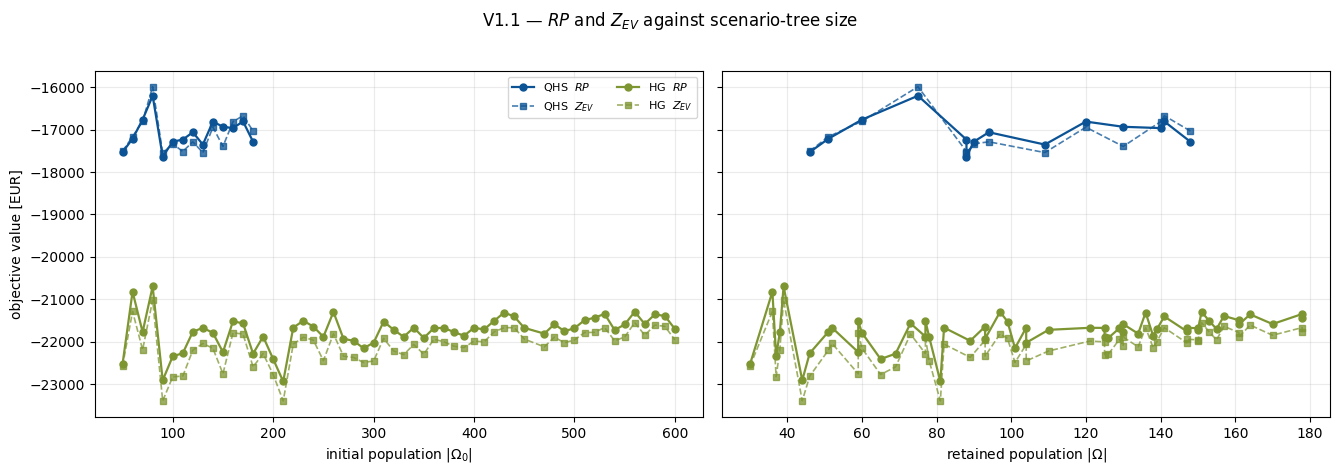

In [10]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PAIR, sharey=True)

for ax, xcol, xlabel in zip(
        axes,
        ["pop_initial", "pop_retained"],
        [r"initial population $|\Omega_0|$", r"retained population $|\Omega|$"]):
    for form in FORMULATIONS:
        sub = scalars[scalars["formulation"] == form].sort_values(xcol)
        ax.plot(sub[xcol], sub["RP"], color=COLORS[form], marker="o", ms=5, lw=1.6,
                label=f"{form}  $RP$")
        ax.plot(sub[xcol], sub["EV"], color=COLORS[form], marker="s", ms=4, lw=1.2,
                ls="--", alpha=0.75, label=f"{form}  $Z_{{EV}}$")
    ax.set_xlabel(xlabel)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("objective value [EUR]")
axes[0].legend(fontsize=8, ncol=2)
finish(fig, r"V1.1 — $RP$ and $Z_{EV}$ against scenario-tree size")

## V1.2 — $Z_{EV} - RP$: does averaging help or hurt?

For a maximisation, a naive Jensen argument would put the averaged problem *above* the
stochastic one, $Z_{EV} \ge RP$. `tab:props` records that this reasoning (Escudero's
Proposition 2) is **not applicable** here, because the objective coefficients are the
stochastic market prices rather than deterministic costs.

The sign of $Z_{EV} - RP$ tests that statement directly against the data, and is the
cheapest empirical evidence the chapter can offer for a claim `tab:props` otherwise makes
on theory alone. A negative value means the averaged problem *underperforms* the
stochastic one — which the Jensen bound would forbid.

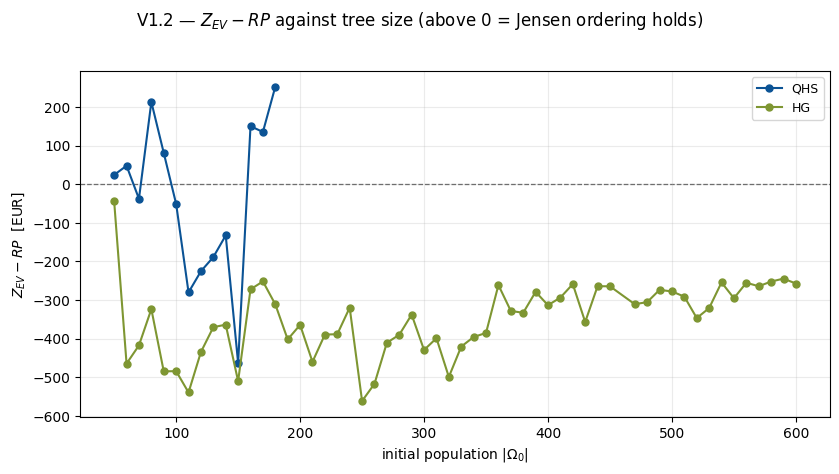

Runs in which the Jensen ordering Z_EV >= RP is observed:
             runs  holds  fails
formulation                    
HG             55      0     55
QHS            14      7      7


In [11]:
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)

for form in FORMULATIONS:
    sub = scalars[scalars["formulation"] == form].sort_values("pop_initial")
    ax.plot(sub["pop_initial"], sub["EV_minus_RP"], color=COLORS[form],
            marker="o", ms=5, lw=1.5, label=form)

zero_line(ax)
ax.set_xlabel(r"initial population $|\Omega_0|$")
ax.set_ylabel(r"$Z_{EV} - RP$  [EUR]")
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
finish(fig, r"V1.2 — $Z_{EV} - RP$ against tree size (above 0 = Jensen ordering holds)")

jensen = (scalars.assign(jensen_ordering_holds=scalars["EV_minus_RP"] >= 0)
          .groupby("formulation")["jensen_ordering_holds"]
          .agg(runs="size", holds="sum"))
jensen["fails"] = jensen["runs"] - jensen["holds"]
print("Runs in which the Jensen ordering Z_EV >= RP is observed:")
print(jensen.to_string())

## V1.3 — $VSS_{T}$ against tree size, in euro and as a share of $\lvert RP \rvert$

The subsection's literal question. $VSS_{T}$ (here $T = 6$, the IB macro-stage) is the
end of the static chain: the cost of having entered *every* market session with a
decision computed from average forecasts.

Both units are shown because they answer different questions. The euro value is what the
community loses; the share of $\lvert RP \rvert$ is the only unit in which trees of
different sizes — whose $RP$ differs — are comparable at all.

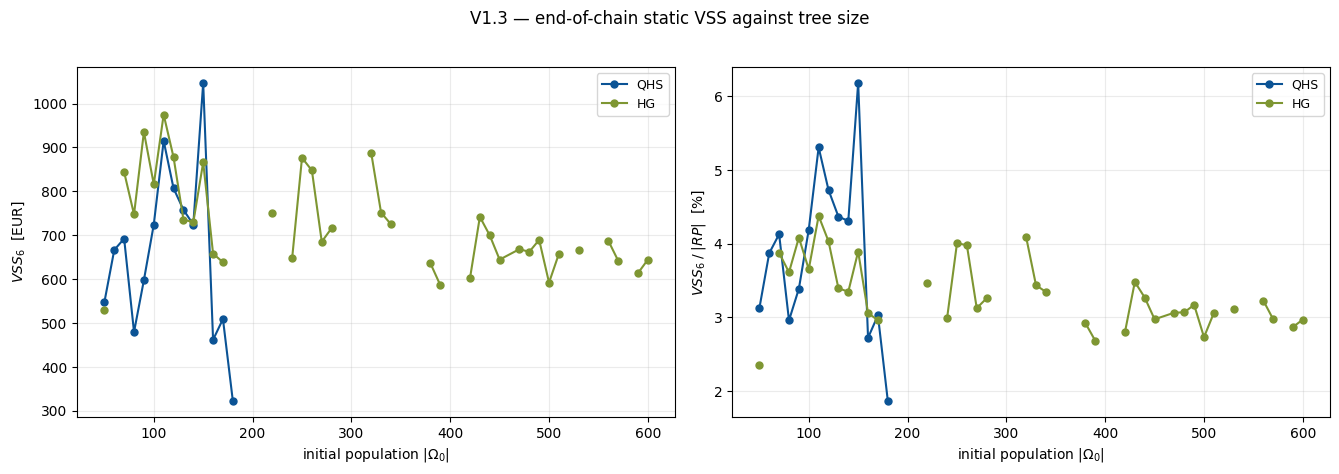

VSS_6 as a share of |RP|, and its correlation with tree size
(correlation reported only where a formulation has more than two runs)
             runs  VSS_pct_min  VSS_pct_max  VSS_pct_mean  corr_with_pop_initial  corr_with_pop_retained
formulation                                                                                             
HG           55.0        2.347        4.377         3.316                 -0.489                  -0.502
QHS          14.0        1.865        6.183         3.869                 -0.091                  -0.123


In [12]:
vss_last = static[static["tau"] == TAU_LAST].copy()

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PAIR)

for form in FORMULATIONS:
    sub = vss_last[vss_last["formulation"] == form].sort_values("pop_initial")
    axes[0].plot(sub["pop_initial"], sub["VSS"], color=COLORS[form],
                 marker="o", ms=5, lw=1.5, label=form)
    axes[1].plot(sub["pop_initial"], sub["VSS_pct_RP"], color=COLORS[form],
                 marker="o", ms=5, lw=1.5, label=form)

axes[0].set_ylabel(rf"$VSS_{{{TAU_LAST}}}$  [EUR]")
axes[1].set_ylabel(rf"$VSS_{{{TAU_LAST}}} \; / \; |RP|$  [%]")
for ax in axes:
    ax.set_xlabel(r"initial population $|\Omega_0|$")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)

finish(fig, r"V1.3 — end-of-chain static VSS against tree size")

trend = (vss_last.groupby("formulation")
         .apply(lambda g: pd.Series({
             "runs": len(g),
             "VSS_pct_min": g["VSS_pct_RP"].min(),
             "VSS_pct_max": g["VSS_pct_RP"].max(),
             "VSS_pct_mean": g["VSS_pct_RP"].mean(),
             "corr_with_pop_initial": (g["VSS_pct_RP"].corr(g["pop_initial"])
                                       if len(g) > 2 else np.nan),
             "corr_with_pop_retained": (g["VSS_pct_RP"].corr(g["pop_retained"].astype(float))
                                        if len(g) > 2 else np.nan),
         }), include_groups=False))
print(f"VSS_{TAU_LAST} as a share of |RP|, and its correlation with tree size")
print("(correlation reported only where a formulation has more than two runs)")
print(trend.round(3).to_string())

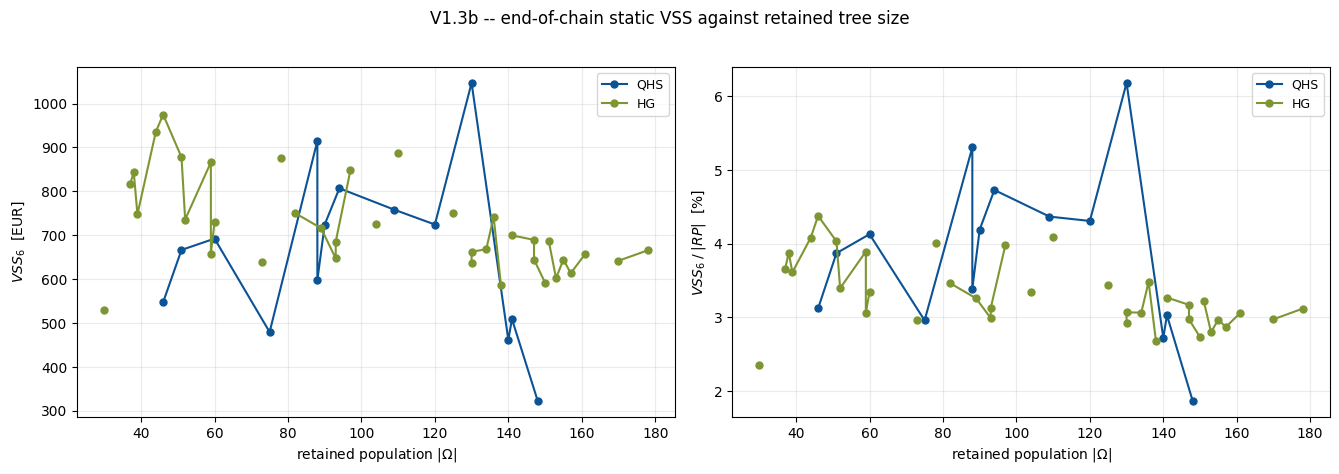

Saved to /users/delfos/aina/TFM_ASP/figures/vss_retained_sweep.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PAIR)

for form in FORMULATIONS:
    sub = vss_last[vss_last["formulation"] == form].sort_values("pop_retained")
    axes[0].plot(sub["pop_retained"], sub["VSS"], color=COLORS[form],
                 marker="o", ms=5, lw=1.5, label=form)
    axes[1].plot(sub["pop_retained"], sub["VSS_pct_RP"], color=COLORS[form],
                 marker="o", ms=5, lw=1.5, label=form)

axes[0].set_ylabel(rf"$VSS_{{{TAU_LAST}}}$  [EUR]")
axes[1].set_ylabel(rf"$VSS_{{{TAU_LAST}}} \; / \; |RP|$  [%]")
for ax in axes:
    ax.set_xlabel(r"retained population $|\Omega|$")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)

finish(fig, r"V1.3b -- end-of-chain static VSS against retained tree size")

# Exported for the thesis (not yet wired in -- companion to V1.3's plot against
# |Omega_0|, this one against the retained count |Omega| instead).
FIGDIR = os.path.join("..", "..", "..", "TFM_ASP", "figures")
fig.savefig(os.path.join(FIGDIR, "vss_retained_sweep.png"), dpi=100)
print(f"Saved to {os.path.abspath(os.path.join(FIGDIR, 'vss_retained_sweep.png'))}")


> **Reading the correlation.** A positive, sizeable correlation would say the measured
> value of stochastic modelling grows with the richness of the tree. A correlation near
> zero says the chain's *level* is set by the day's realised prices rather than by how
> many scenarios represent them — in which case the subsection's finding is the absence
> of a trend, not its shape. Report whichever the data shows; do not read a trend into a
> correlation the run count cannot support.

## V1.4 -- The dynamic chain against tree size

The same question for the dynamic chain: $VSS^D_{T}$, as a share of $\lvert RP \rvert$.

`tab:props` marks Proposition 5 ($VSS^D \ge 0$) as **not guaranteed** in this model, with
`prop:vssd-failure` supplying the mechanism: the per-group day-ahead solutions are chosen
independently and their assembled point violates the cross-group monotonicity constraint
`eq:da-mono`, so the inference $EDEV_T \le RP$ fails. Values below the zero line are
therefore the *predicted* behaviour, not an anomaly.


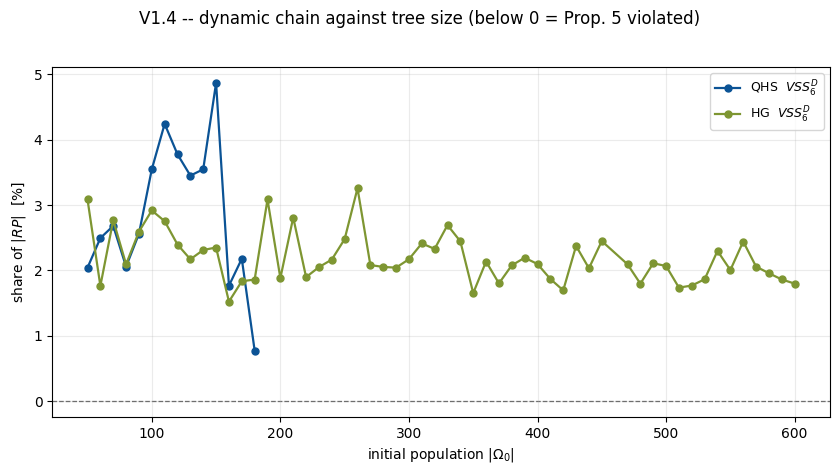

Proposition 5 (VSS^D_6 >= 0) by formulation:
             runs  holds  violates
formulation                       
HG             55     55         0
QHS            14     14         0


In [14]:
vssd_last = dynamic[dynamic["tau"] == TAU_LAST].copy()

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)

for form in FORMULATIONS:
    sub = vssd_last[vssd_last["formulation"] == form].sort_values("pop_initial")
    ax.plot(sub["pop_initial"], sub["VSSD_pct_RP"], color=COLORS[form],
            marker="o", ms=5, lw=1.6, label=rf"{form}  $VSS^D_{{{TAU_LAST}}}$")

zero_line(ax)
ax.set_xlabel(r"initial population $|\Omega_0|$")
ax.set_ylabel(r"share of $|RP|$  [%]")
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
finish(fig, r"V1.4 -- dynamic chain against tree size (below 0 = Prop. 5 violated)")

prop5 = (vssd_last.assign(prop5_holds=vssd_last["VSSD_pct_RP"] >= -VALIDATION_TOL)
         .groupby("formulation")["prop5_holds"].agg(runs="size", holds="sum"))
prop5["violates"] = prop5["runs"] - prop5["holds"]
print(f"Proposition 5 (VSS^D_{TAU_LAST} >= 0) by formulation:")
print(prop5.to_string())


## V1.3c -- Static and dynamic sweeps side by side, both formulations overlaid

The thesis figure for this subsection: $VSS_6/|RP|$ (left) and $VSS^D_6/|RP|$ (right), both with QHS and HG overlaid on the same axes rather than split into separate panels, so the two formulations are compared directly at every $|\Omega_0|$ rather than only through the summary statistics of Table~V1.3/V1.4.


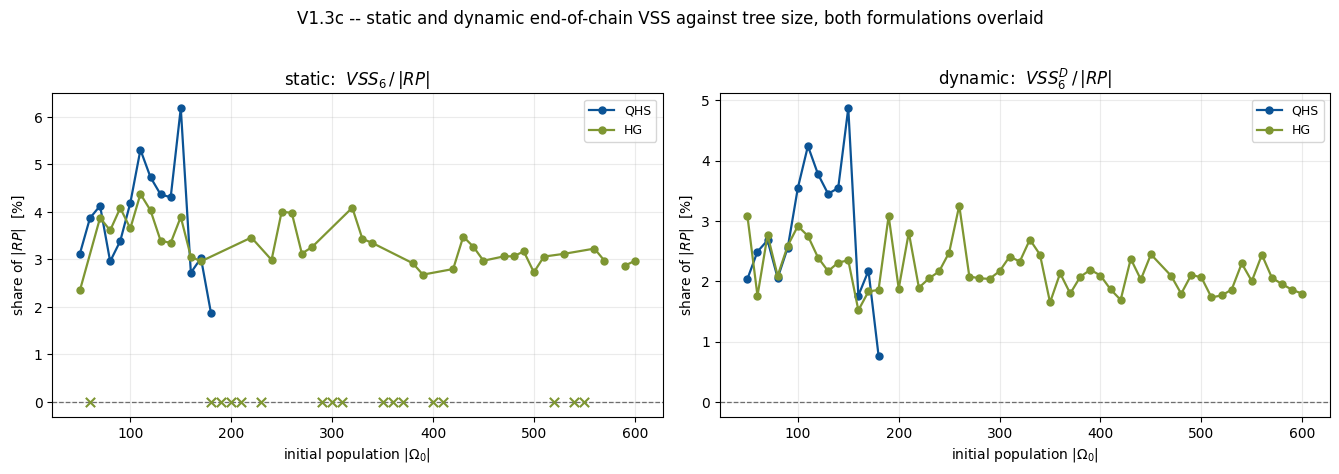

In [15]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PAIR, sharex=False)

for form in FORMULATIONS:
    sub = vss_last[vss_last["formulation"] == form].sort_values("pop_initial")
    feas = sub[sub["excluded_mass"] < 0.999]
    infeas = sub[sub["excluded_mass"] >= 0.999]
    axes[0].plot(feas["pop_initial"], feas["VSS_pct_RP"], color=COLORS[form],
                 marker="o", ms=5, lw=1.6, label=form)
    if not infeas.empty:
        axes[0].scatter(infeas["pop_initial"], [0] * len(infeas), color=COLORS[form],
                        marker="x", s=45, zorder=5)

for form in FORMULATIONS:
    sub = vssd_last[vssd_last["formulation"] == form].sort_values("pop_initial")
    axes[1].plot(sub["pop_initial"], sub["VSSD_pct_RP"], color=COLORS[form],
                 marker="o", ms=5, lw=1.6, label=form)

axes[0].set_title(r"static:  $VSS_6 \,/\, |RP|$")
axes[1].set_title(r"dynamic:  $VSS^D_6 \,/\, |RP|$")
for ax in axes:
    ax.set_xlabel(r"initial population $|\Omega_0|$")
    ax.set_ylabel(r"share of $|RP|$  [%]")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)
zero_line(axes[0])
zero_line(axes[1])
finish(fig, r"V1.3c -- static and dynamic end-of-chain VSS against tree size, "
            r"both formulations overlaid")


## V1.5 — The whole static chain, across every tree

$VSS_\tau$ for $\tau = 1,\dots,6$, one line per scenario tree. Where V1.3 asks whether
the chain's *level* moves with tree size, this asks whether its *shape* does — whether
the tree changes at which market session the information becomes valuable, or only how
much it is worth.

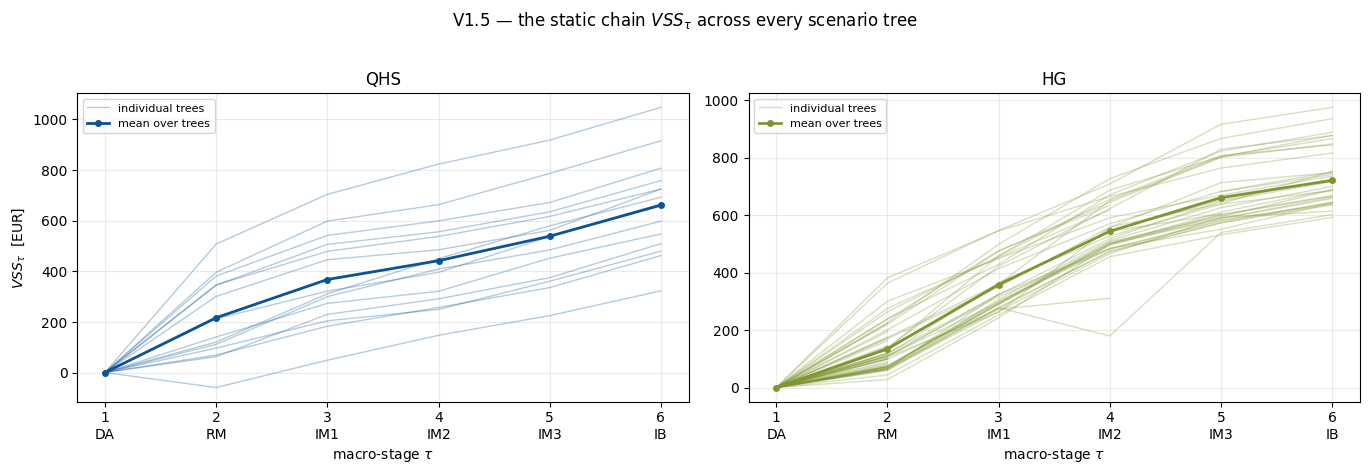

In [16]:
n_panels = len(FORMULATIONS)
fig, axes = plt.subplots(1, n_panels, figsize=(6.9 * n_panels, 4.6), squeeze=False)

for ax, form in zip(axes[0], FORMULATIONS):
    plot_per_run_lines(ax, static, "VSS", form, alpha=0.30, lw=1.0,
                       label="individual trees")
    plot_band(ax, static, "VSS", form, alpha=0.0, label="mean over trees")
    stage_axis(ax)
    ax.set_title(form)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

axes[0][0].set_ylabel(r"$VSS_\tau$  [EUR]")
finish(fig, r"V1.5 — the static chain $VSS_\tau$ across every scenario tree")

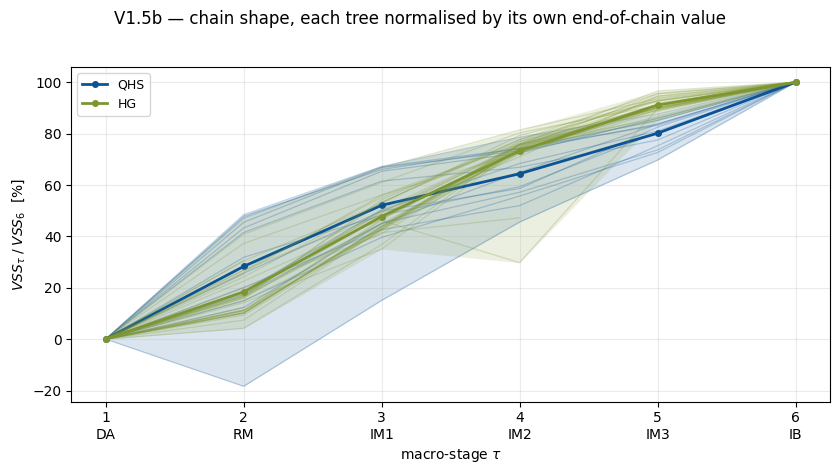

In [17]:
# Normalised shape: each tree's chain divided by its own end-of-chain value, so the
# curves are directly comparable regardless of level. VSS_1 = 0 by construction.
shape = static.copy()
end_of_chain = (shape[shape["tau"] == TAU_LAST]
                .set_index("run_dir")["VSS"].rename("VSS_end"))
shape = shape.join(end_of_chain, on="run_dir")
shape["VSS_share_of_end"] = 100.0 * shape["VSS"] / shape["VSS_end"]

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
for form in FORMULATIONS:
    plot_per_run_lines(ax, shape, "VSS_share_of_end", form, alpha=0.25, lw=0.9)
    plot_band(ax, shape, "VSS_share_of_end", form, alpha=0.15, label=form)

stage_axis(ax)
ax.set_ylabel(rf"$VSS_\tau \; / \; VSS_{{{TAU_LAST}}}$  [%]")
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
finish(fig, r"V1.5b — chain shape, each tree normalised by its own end-of-chain value")

## V1.6 — Runs that stand apart

Three properties single a run out for comment rather than for exclusion: it is the only
one of its formulation for which the dynamic measure is non-negative; its $RP$ does not
reconcile with the execution batch (Section 0.2); or its retained tree is far smaller
than the rest of its formulation's.

The rule is evaluated over whatever runs are present, so this table updates itself as
runs are added. Nothing is dropped on the strength of it.

In [18]:
flags = provenance[["formulation", "run_dir", "pop_initial", "pop_retained",
                    "in_batch", "reconciles"]].copy()
flags = flags.merge(
    vssd_last[["run_dir", "VSSD_pct_RP"]].rename(columns={"VSSD_pct_RP": "VSSD_last_pct_RP"}),
    on="run_dir", how="left")
flags = flags.merge(
    vss_last[["run_dir", "VSS_pct_RP"]].rename(columns={"VSS_pct_RP": "VSS_last_pct_RP"}),
    on="run_dir", how="left")

# Flag 1: dynamic measure non-negative -- rare enough here to be worth naming.
flags["dynamic_nonneg"] = flags["VSSD_last_pct_RP"] >= -VALIDATION_TOL

# Flag 2: no execution-batch counterpart at all.
flags["absent_from_batch"] = ~flags["in_batch"]

# Flag 3: retained tree far below its own formulation's median. Half the median is a
# blunt threshold, stated here rather than buried, and only meaningful once a
# formulation has several runs.
median_retained = flags.groupby("formulation")["pop_retained"].transform("median")
group_size = flags.groupby("formulation")["run_dir"].transform("size")
flags["small_tree"] = (group_size > 2) & (flags["pop_retained"].astype(float)
                                          < 0.5 * median_retained.astype(float))

flag_cols = ["dynamic_nonneg", "absent_from_batch", "small_tree"]
flags["n_flags"] = flags[flag_cols].sum(axis=1)

flagged = flags[flags["n_flags"] > 0].sort_values(["formulation", "pop_initial"])
if flagged.empty:
    print("No run triggers any of the three flags.")
else:
    print("Runs triggering at least one flag (reported, not excluded):")
flagged[["formulation", "run_dir", "pop_initial", "pop_retained",
         "VSS_last_pct_RP", "VSSD_last_pct_RP"] + flag_cols].reset_index(drop=True)

Runs triggering at least one flag (reported, not excluded):


,formulation,run_dir,pop_initial,pop_retained,VSS_last_pct_RP,VSSD_last_pct_RP,dynamic_nonneg,absent_from_batch,small_tree
0,HG,FTC_20251031_20251130_c31_sc50_15min_same_ren,50,30,2.347382,3.082861,True,False,True
1,HG,FTC_20251031_20251130_c31_sc60_15min_same_ren,60,36,NaN,1.759606,True,False,True
2,HG,FTC_20251031_20251130_c31_sc70_15min_same_ren,70,38,3.875887,2.766019,True,False,True
3,HG,FTC_20251031_20251130_c31_sc80_15min_same_ren,80,39,3.610703,2.091018,True,False,True
4,HG,FTC_20251031_20251130_c31_sc90_15min_same_ren,90,44,4.082168,2.589952,True,False,True
5,HG,FTC_20251031_20251130_c31_sc100_15min_same_ren,100,37,3.652008,2.914362,True,False,True
6,HG,FTC_20251031_20251130_c31_sc110_15min_same_ren,110,46,4.376836,2.750778,True,False,True
7,HG,FTC_20251031_20251130_c31_sc120_15min_same_ren,120,51,4.031935,2.392991,True,False,True
8,HG,FTC_20251031_20251130_c31_sc130_15min_same_ren,130,52,3.394535,2.167269,True,False,False
9,HG,FTC_20251031_20251130_c31_sc140_15min_same_ren,140,60,3.346925,2.309394,True,False,False


---
# 4.3.2 — VSS comparison between the two formulations
`\label{subsec:results-vss-formulations}`

> *"VSS obtained under the QHS and HG formulations, and what the comparison indicates
> about the value of the intra-hour information that the HG formulation declines to
> use."*

This subsection holds the tree fixed as far as the data allows and varies the
formulation.

**Two constraints on what may be concluded here, both stated before any number is
shown.**

1. **Matching.** The comparison is only clean at equal $\lvert\Omega\rvert$. Section
   5.2's design achieves that by pairing runs at matched retained counts; whether the
   VSS runs admit the same pairing is an empirical question, answered by V2.1 rather
   than assumed. Where no exact match exists, the nearest counterpart is used and the
   gap is reported in its own column.
2. **Attribution.** Even at a matched count, a difference between the two chains is not
   attributable to the stage structure alone — the confounding of `rem:confounding`
   applies here exactly as it does in Section 4.2. The figures below report *what*
   differs; they do not establish *why*.

## V2.1 — Head-to-head at matched (or nearest) retained tree size

Each formulation's runs are paired with the other's by retained population
$\lvert\Omega\rvert$: exactly where a common count exists, otherwise with the nearest
available counterpart. The `retained_gap` column is the pairing error, and is the first
thing to read — a pairing across a large gap is a comparison of two different problems.

Reported in **absolute euro** here and in **shares of $\lvert RP \rvert$** immediately
below, per the caveat of Section 0.2: the absolute table is only interpretable between
runs that reconcile with the same execution batch.

In [19]:
# ---------------------------------------------------------------------------
# Pairing (V2.1). Generic over formulations and run counts: for every run of each
# formulation, find the counterpart of the other formulation whose retained tree is
# closest, and record the pairing error.
# ---------------------------------------------------------------------------
def nearest_counterpart(cov, form_a, form_b):
    left = cov[cov["formulation"] == form_a]
    right = cov[cov["formulation"] == form_b]
    if left.empty or right.empty:
        return pd.DataFrame()

    pairs = []
    for row in left.itertuples():
        gaps = (right["pop_retained"].astype(float) - float(row.pop_retained)).abs()
        best = right.loc[gaps.idxmin()]
        pairs.append({
            f"{form_a}_run": row.run_dir,
            f"{form_a}_pop_initial": row.pop_initial,
            f"{form_a}_pop_retained": row.pop_retained,
            f"{form_b}_run": best["run_dir"],
            f"{form_b}_pop_initial": best["pop_initial"],
            f"{form_b}_pop_retained": best["pop_retained"],
            "retained_gap": int(abs(int(row.pop_retained) - int(best["pop_retained"]))),
            "exact_match": int(row.pop_retained) == int(best["pop_retained"]),
        })
    return pd.DataFrame(pairs)


# Pair from the scarcer formulation outwards: that side is the binding constraint.
counts = coverage["formulation"].value_counts()
if len(FORMULATIONS) < 2:
    pairs = pd.DataFrame()
    print("Only one formulation has VSS data; no cross-formulation pairing is possible.")
else:
    form_scarce = counts.idxmin()
    form_rich = [f for f in FORMULATIONS if f != form_scarce][0]
    pairs = nearest_counterpart(coverage, form_scarce, form_rich)
    print(f"pairing {form_scarce} ({counts[form_scarce]} runs) against "
          f"{form_rich} ({counts[form_rich]} runs)")
    print(f"exact |Omega| matches: {int(pairs['exact_match'].sum())} of {len(pairs)}")

pairs

pairing QHS (14 runs) against HG (55 runs)
exact |Omega| matches: 5 of 14


,QHS_run,QHS_pop_initial,QHS_pop_retained,HG_run,HG_pop_initial,HG_pop_retained,retained_gap,exact_match
0,FTC_20251031_20251130_c31_sc50_15min_different...,50,46,FTC_20251031_20251130_c31_sc110_15min_same_ren,110,46,0,True
1,FTC_20251031_20251130_c31_sc60_15min_different...,60,51,FTC_20251031_20251130_c31_sc120_15min_same_ren,120,51,0,True
2,FTC_20251031_20251130_c31_sc70_15min_different...,70,60,FTC_20251031_20251130_c31_sc140_15min_same_ren,140,60,0,True
3,FTC_20251031_20251130_c31_sc80_15min_different...,80,75,FTC_20251031_20251130_c31_sc170_15min_same_ren,170,73,2,False
4,FTC_20251031_20251130_c31_sc90_15min_different...,90,88,FTC_20251031_20251130_c31_sc280_15min_same_ren,280,89,1,False
5,FTC_20251031_20251130_c31_sc100_15min_differen...,100,90,FTC_20251031_20251130_c31_sc280_15min_same_ren,280,89,1,False
6,FTC_20251031_20251130_c31_sc110_15min_differen...,110,88,FTC_20251031_20251130_c31_sc280_15min_same_ren,280,89,1,False
7,FTC_20251031_20251130_c31_sc120_15min_differen...,120,94,FTC_20251031_20251130_c31_sc240_15min_same_ren,240,93,1,False
8,FTC_20251031_20251130_c31_sc130_15min_differen...,130,109,FTC_20251031_20251130_c31_sc320_15min_same_ren,320,110,1,False
9,FTC_20251031_20251130_c31_sc140_15min_differen...,140,120,FTC_20251031_20251130_c31_sc400_15min_same_ren,400,121,1,False


In [20]:
# ---------------------------------------------------------------------------
# The per-run quantity block both comparison tables draw on.
# ---------------------------------------------------------------------------
headline = (scalars[["formulation", "run_dir", "pop_initial", "pop_retained",
                     "RP", "EV", "EV_minus_RP", "reconciles"]]
            .merge(static.loc[static["tau"] == TAU_LAST,
                              ["run_dir", "VSS", "VSS_pct_RP", "excluded_mass"]]
                   .rename(columns={"VSS": f"VSS_{TAU_LAST}",
                                    "VSS_pct_RP": f"VSS_{TAU_LAST}_pct_RP",
                                    "excluded_mass": "static_excluded_mass_last"}),
                   on="run_dir")
            .merge(dynamic.loc[dynamic["tau"] == TAU_LAST,
                               ["run_dir", "VSSD", "VSSD_pct_RP", "excluded_mass"]]
                   .rename(columns={"VSSD": f"VSSD_{TAU_LAST}",
                                    "VSSD_pct_RP": f"VSSD_{TAU_LAST}_pct_RP",
                                    "excluded_mass": "dynamic_excluded_mass_last"}),
                   on="run_dir"))

# Peak excluded mass over the whole chain, not only at the last stage: the chapter's
# reporting frame asks for the mass discarded alongside every affected value.
headline["static_excluded_mass_max"] = headline["run_dir"].map(
    static.groupby("run_dir")["excluded_mass"].max())
headline["dynamic_excluded_mass_max"] = headline["run_dir"].map(
    dynamic.groupby("run_dir")["excluded_mass"].max())

headline = headline.sort_values(["formulation", "pop_initial"]).reset_index(drop=True)
headline


,formulation,run_dir,pop_initial,pop_retained,RP,EV,EV_minus_RP,reconciles,VSS_6,VSS_6_pct_RP,static_excluded_mass_last,VSSD_6,VSSD_6_pct_RP,dynamic_excluded_mass_last,static_excluded_mass_max,dynamic_excluded_mass_max
0,HG,FTC_20251031_20251130_c31_sc50_15min_same_ren,50,30,-22533.476012,-22578.086900,-44.610887,True,528.946862,2.347382,0.080000,694.675793,3.082861,0.000000,1.000000,0.000000
1,HG,FTC_20251031_20251130_c31_sc60_15min_same_ren,60,36,-20822.962923,-21287.612080,-464.649157,True,NaN,NaN,1.000000,366.402121,1.759606,0.000000,1.000000,0.000000
2,HG,FTC_20251031_20251130_c31_sc70_15min_same_ren,70,38,-21773.894036,-22191.261261,-417.367224,True,843.931611,3.875887,0.000000,602.269944,2.766019,0.000000,0.000000,0.000000
3,HG,FTC_20251031_20251130_c31_sc80_15min_same_ren,80,39,-20698.985488,-21022.453714,-323.468226,True,747.378910,3.610703,0.000000,432.819518,2.091018,0.000000,0.000000,0.000000
4,HG,FTC_20251031_20251130_c31_sc90_15min_same_ren,90,44,-22911.968193,-23396.642474,-484.674281,True,935.305144,4.082168,0.000000,593.409060,2.589952,0.000000,0.000000,0.000000
5,HG,FTC_20251031_20251130_c31_sc100_15min_same_ren,100,37,-22344.797530,-22828.927270,-484.129740,True,816.033742,3.652008,0.000000,651.208279,2.914362,0.000000,0.000000,0.000000
6,HG,FTC_20251031_20251130_c31_sc110_15min_same_ren,110,46,-22273.824604,-22813.155401,-539.330797,True,974.888825,4.376836,0.000000,612.703498,2.750778,0.009091,0.000000,0.009091
7,HG,FTC_20251031_20251130_c31_sc120_15min_same_ren,120,51,-21767.678847,-22202.207814,-434.528967,True,877.658678,4.031935,0.000000,520.898527,2.392991,0.000000,0.000000,0.000000
8,HG,FTC_20251031_20251130_c31_sc130_15min_same_ren,130,52,-21673.726987,-22043.973855,-370.246868,True,735.722298,3.394535,0.000000,469.728011,2.167269,0.046154,0.000000,0.046154
9,HG,FTC_20251031_20251130_c31_sc140_15min_same_ren,140,60,-21793.404242,-22157.084894,-363.680653,True,729.408896,3.346925,0.000000,503.295618,2.309394,0.000000,1.000000,0.000000


In [21]:
# ---------------------------------------------------------------------------
# V2.1a -- ABSOLUTE comparison table, at the pairing established above.
# Read with the Section 0.2 caveat: euro values from runs that do not reconcile
# with the same execution batch are not on the same footing.
# ---------------------------------------------------------------------------
ABS_COLS = ["RP", "EV", f"VSS_{TAU_LAST}", f"VSSD_{TAU_LAST}"]
REL_COLS = [f"VSS_{TAU_LAST}_pct_RP", f"VSSD_{TAU_LAST}_pct_RP"]
CTX_COLS = ["pop_initial", "pop_retained", "static_excluded_mass_max",
            "dynamic_excluded_mass_max", "reconciles"]


def comparison_table(pairs_df, value_cols):
    """One row per pairing, one column block per formulation."""
    if pairs_df.empty:
        return pd.DataFrame()
    idx = headline.set_index("run_dir")
    rows = []
    a, b = form_scarce, form_rich
    for p in pairs_df.itertuples():
        ra, rb = idx.loc[getattr(p, f"{a}_run")], idx.loc[getattr(p, f"{b}_run")]
        row = {"retained_gap": p.retained_gap, "exact_match": p.exact_match}
        for form, r in ((a, ra), (b, rb)):
            for c in CTX_COLS + value_cols:
                row[f"{form}.{c}"] = r[c]
        rows.append(row)
    return pd.DataFrame(rows)


abs_table = comparison_table(pairs, ABS_COLS)
print("V2.1a -- absolute comparison [EUR]")
abs_table


V2.1a -- absolute comparison [EUR]


,retained_gap,exact_match,QHS.pop_initial,QHS.pop_retained,QHS.static_excluded_mass_max,QHS.dynamic_excluded_mass_max,QHS.reconciles,QHS.RP,QHS.EV,QHS.VSS_6,QHS.VSSD_6,HG.pop_initial,HG.pop_retained,HG.static_excluded_mass_max,HG.dynamic_excluded_mass_max,HG.reconciles,HG.RP,HG.EV,HG.VSS_6,HG.VSSD_6
0,0,True,50,46,0.0,0.0,True,-17533.559617,-17509.352578,547.237009,357.358532,110,46,0.0,0.009091,True,-22273.824604,-22813.155401,974.888825,612.703498
1,0,True,60,51,0.0,0.0,True,-17217.317235,-17169.381158,666.371516,429.025335,120,51,0.0,0.000000,True,-21767.678847,-22202.207814,877.658678,520.898527
2,0,True,70,60,0.0,0.0,True,-16767.168517,-16804.854714,692.169381,449.067287,140,60,1.0,0.000000,True,-21793.404242,-22157.084894,729.408896,503.295618
3,2,False,80,75,0.0,0.0,True,-16204.060256,-15990.920833,479.257028,332.939021,170,73,0.0,0.000000,True,-21570.619251,-21822.321050,638.365963,394.902488
4,1,False,90,88,0.0,0.0,True,-17639.689939,-17558.461878,597.637123,451.046682,280,89,0.0,0.000000,True,-21981.333602,-22371.272647,716.136952,450.580945
5,1,False,100,90,0.0,0.0,True,-17285.647130,-17336.668373,724.375677,612.787348,280,89,0.0,0.000000,True,-21981.333602,-22371.272647,716.136952,450.580945
6,1,False,110,88,0.0,0.0,True,-17238.018757,-17518.148975,914.946337,730.952335,280,89,0.0,0.000000,True,-21981.333602,-22371.272647,716.136952,450.580945
7,1,False,120,94,0.0,0.0,True,-17064.283748,-17289.593640,806.885009,643.931749,240,93,1.0,0.000000,True,-21644.549063,-21964.221190,647.061591,468.059858
8,1,False,130,109,0.0,0.0,True,-17354.755091,-17543.378843,757.938760,598.436265,320,110,0.0,0.012500,True,-21721.807071,-22220.900271,888.066023,505.309684
9,1,False,140,120,0.0,0.0,True,-16813.024272,-16945.605461,724.325874,596.012148,400,121,1.0,0.035000,True,-21674.257078,-21987.594493,NaN,454.043211


In [22]:
# ---------------------------------------------------------------------------
# V2.1b -- RELATIVE comparison table. Shares of |RP| are the unit in which runs
# with different RP -- and, here, different provenance -- may legitimately be
# compared.
# ---------------------------------------------------------------------------
rel_table = comparison_table(pairs, REL_COLS)
print("V2.1b -- comparison as shares of |RP| [%]")
rel_table

V2.1b -- comparison as shares of |RP| [%]


,retained_gap,exact_match,QHS.pop_initial,QHS.pop_retained,QHS.static_excluded_mass_max,QHS.dynamic_excluded_mass_max,QHS.reconciles,QHS.VSS_6_pct_RP,QHS.VSSD_6_pct_RP,HG.pop_initial,HG.pop_retained,HG.static_excluded_mass_max,HG.dynamic_excluded_mass_max,HG.reconciles,HG.VSS_6_pct_RP,HG.VSSD_6_pct_RP
0,0,True,50,46,0.0,0.0,True,3.121083,2.038140,110,46,0.0,0.009091,True,4.376836,2.750778
1,0,True,60,51,0.0,0.0,True,3.870356,2.491825,120,51,0.0,0.000000,True,4.031935,2.392991
2,0,True,70,60,0.0,0.0,True,4.128123,2.678254,140,60,1.0,0.000000,True,3.346925,2.309394
3,2,False,80,75,0.0,0.0,True,2.957635,2.054664,170,73,0.0,0.000000,True,2.959423,1.830742
4,1,False,90,88,0.0,0.0,True,3.388025,2.556999,280,89,0.0,0.000000,True,3.257932,2.049834
5,1,False,100,90,0.0,0.0,True,4.190619,3.545065,280,89,0.0,0.000000,True,3.257932,2.049834
6,1,False,110,88,0.0,0.0,True,5.307723,4.240350,280,89,0.0,0.000000,True,3.257932,2.049834
7,1,False,120,94,0.0,0.0,True,4.728502,3.773564,240,93,1.0,0.000000,True,2.989490,2.162484
8,1,False,130,109,0.0,0.0,True,4.367326,3.448255,320,110,0.0,0.012500,True,4.088362,2.326278
9,1,False,140,120,0.0,0.0,True,4.308124,3.544943,400,121,1.0,0.035000,True,NaN,2.094850


> ### Caveat attached to the absolute table
>
> The absolute euro comparison (V2.1a) presumes both sides were produced by the same
> experimental pipeline. Section 0.2 checks that presumption run by run, and the
> `reconciles` column is carried into the table above so it cannot be read without it.
>
> Where a run does not reconcile, **read V2.1b and not V2.1a**: shares of
> $\lvert RP \rvert$ are internal to each run and survive a provenance break that euro
> values do not. Where the `retained_gap` column is non-zero, neither table is a matched
> comparison — it is the closest one the available runs permit, and the gap is the size
> of the compromise.

## V2.2 / V2.3 — Both chains, both formulations, in shares of $\lvert RP \rvert$

The whole chain rather than its endpoint, in the one unit that is comparable across
formulations. Where a formulation has several runs, the band is its min–max envelope
across scenario trees and the solid line its mean; where it has one, the line is that
run.

Reading the two panels together is the point: the static chain descends from zero into
positive territory (the comparator is always worse than $RP$), while the dynamic chain
sits *below* zero (the comparator scores better than $RP$, which `prop:vssd-failure`
predicts and Section 4.3.3 dissects).

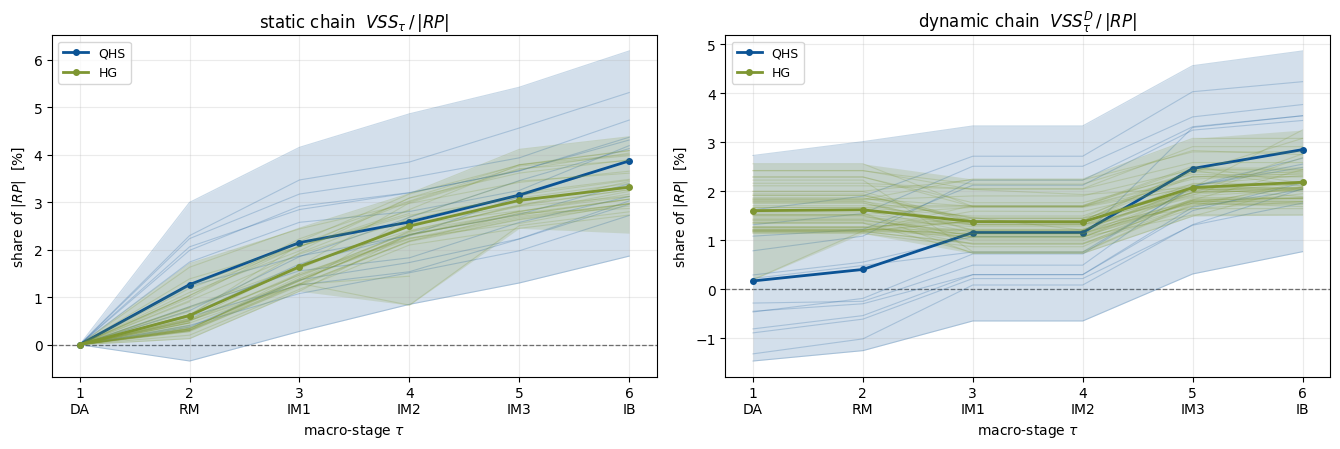

Saved to /users/delfos/aina/TFM_ASP/figures/vss_value_sweep.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PAIR, sharex=True)

for form in FORMULATIONS:
    plot_per_run_lines(axes[0], static, "VSS_pct_RP", form, alpha=0.22, lw=0.8)
    plot_band(axes[0], static, "VSS_pct_RP", form, label=form)
    plot_per_run_lines(axes[1], dynamic, "VSSD_pct_RP", form, alpha=0.22, lw=0.8)
    plot_band(axes[1], dynamic, "VSSD_pct_RP", form, label=form)

axes[0].set_title(r"static chain  $VSS_\tau \,/\, |RP|$")
axes[1].set_title(r"dynamic chain  $VSS^D_\tau \,/\, |RP|$")
for ax in axes:
    stage_axis(ax)
    zero_line(ax)
    ax.set_ylabel(r"share of $|RP|$  [%]")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)

finish(fig)

# Exported for the thesis annex (sec:annex-vss-results), parallel to
# fig:vss-excluded-mass-sweep (V2.5) but for VSS_tau/VSSD_tau rather than
# excluded mass.
FIGDIR = os.path.join("..", "..", "..", "TFM_ASP", "figures")
fig.savefig(os.path.join(FIGDIR, "vss_value_sweep.png"), dpi=100)
print(f"Saved to {os.path.abspath(os.path.join(FIGDIR, 'vss_value_sweep.png'))}")

## V2.4 — Does $EDEV_2 = EDEV_1$ hold in each formulation?

`tab:props` lists $EDEV_2 = EDEV_1$ as **expected**, on the argument of
`subsec:vss-macrostages`: reserve bids are submitted alongside the day-ahead bids, before
the day-ahead market clears, so both are nonanticipative with respect to the same
stage-1 clustering and $\mathcal{G}_2 = \mathcal{G}_1$ as a partition. `validation.py`
encodes the same reasoning in a note rather than as a test.

The argument is about *this model's market timeline*, so it is worth checking whether it
survives in both stage structures. The check costs nothing and speaks directly to the
subsection's question about intra-hour information: if the identity holds under one
formulation and not the other, the two disagree on whether the reserve macro-stage
carries information the day-ahead stage did not.

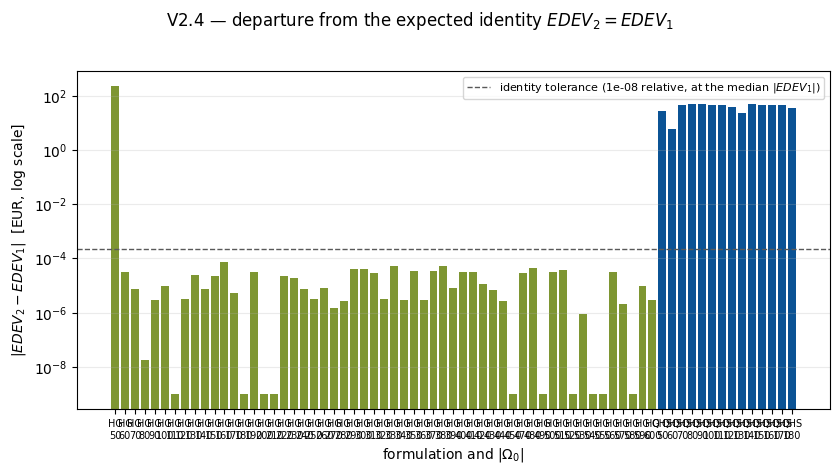

EDEV_2 == EDEV_1, by formulation:
             runs  identity_holds  max_abs_diff_EUR  max_rel_diff  identity_fails
formulation                                                                      
HG             55              54               224       0.00994               1
QHS            14               0              50.2        0.0031              14


In [24]:
edev = dynamic.pivot_table(index=["formulation", "run_dir", "pop_initial"],
                           columns="tau", values="EDEV").reset_index()
edev["EDEV_2_minus_EDEV_1"] = edev[2] - edev[1]
edev["abs_diff"] = edev["EDEV_2_minus_EDEV_1"].abs()
edev["rel_diff"] = edev["abs_diff"] / edev[1].abs()
# Scale-aware: these are ~1e4 EUR quantities, so an absolute 1e-6 threshold would
# test the 11th significant digit and fail on solver float noise. See the
# IDENTITY_REL_TOL note in the setup cell.
edev["identity_holds"] = [equal_within_scale(a, b) for a, b in zip(edev[2], edev[1])]
edev = edev.sort_values(["formulation", "pop_initial"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
positions = np.arange(len(edev))
ax.bar(positions, edev["abs_diff"].clip(lower=1e-9),
       color=[COLORS[f] for f in edev["formulation"]])
ax.axhline(IDENTITY_REL_TOL * edev[1].abs().median(), color="0.35", lw=1.0, ls="--",
           label=f"identity tolerance ({IDENTITY_REL_TOL:g} relative, at the median $|EDEV_1|$)")
ax.set_yscale("log")
ax.set_xticks(positions)
ax.set_xticklabels([f"{f}\n{p}" for f, p in zip(edev["formulation"], edev["pop_initial"])],
                   fontsize=7)
ax.set_xlabel(r"formulation and $|\Omega_0|$")
ax.set_ylabel(r"$|EDEV_2 - EDEV_1|$  [EUR, log scale]")
ax.grid(alpha=0.25, axis="y")
ax.legend(fontsize=8)
finish(fig, r"V2.4 — departure from the expected identity $EDEV_2 = EDEV_1$")

verdict = edev.groupby("formulation").agg(
    runs=("run_dir", "size"),
    identity_holds=("identity_holds", "sum"),
    max_abs_diff_EUR=("abs_diff", "max"),
    max_rel_diff=("rel_diff", "max"))
verdict["identity_fails"] = verdict["runs"] - verdict["identity_holds"]
print("EDEV_2 == EDEV_1, by formulation:")
print(verdict.to_string(float_format=lambda v: f"{v:.3g}"))

> **If the identity fails for a formulation, that is a `tab:props` correction, not a
> plot artefact.** The table states the identity unconditionally; a formulation in which
> the stage-1 and stage-2 fixings are not equivalent needs the row scoped to the
> formulations in which it actually holds. Flag it for the methods chapter rather than
> plotting around it.

## V2.5 — Probability mass discarded, by macro-stage and formulation

The reporting frame's second item. `subsec:vss-exclusion` requires the excluded mass to
appear beside every value it produced: *"A value obtained after discarding a
non-negligible share of the probability mass is a value computed on a different problem,
and reporting the two together is what keeps it honest."*

Two distinct mechanisms write into this column, and they are not interchangeable:

- **Static chain** — scenario-level exclusion driven by a Gurobi IIS
  (`subsec:vss-exclusion`), used because the natural unit of failure there is an
  individual scenario.
- **Dynamic chain** — group-level exclusion (`edev_vssd.compute_edev_t`), matching the
  granularity at which its subproblems are defined; surviving groups' weights are
  renormalised to sum to one.

It belongs in *this* subsection because, as of the present data, it is a difference
*between* the formulations rather than a uniform background condition.

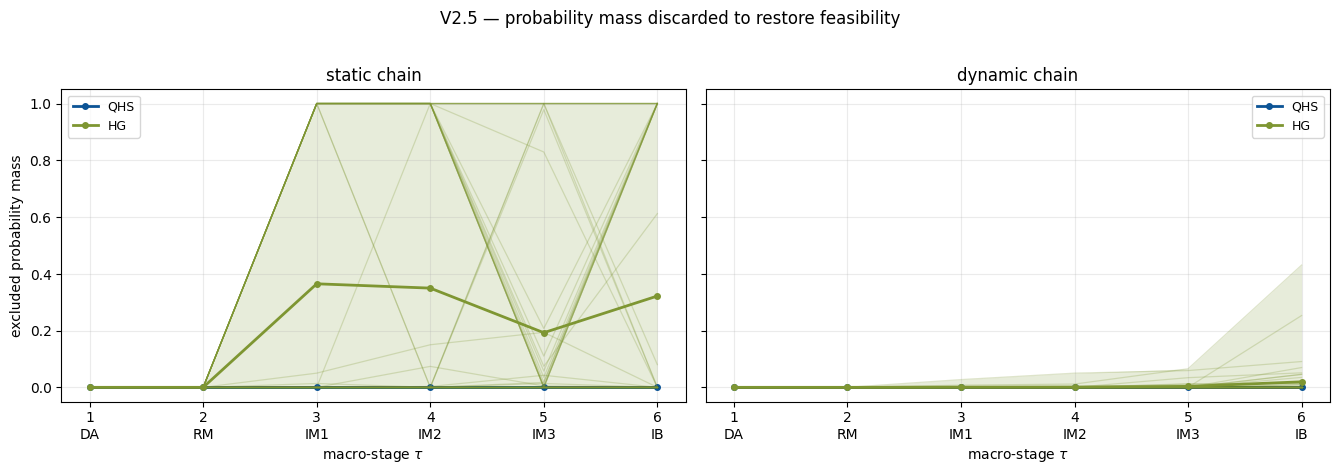

Maximum excluded probability mass, by chain, formulation and macro-stage:
tau                    1    2       3     4       5       6
chain   formulation                                        
dynamic HG           0.0  0.0  0.0273  0.05  0.0654  0.4308
        QHS          0.0  0.0  0.0000  0.00  0.0000  0.0000
static  HG           0.0  0.0  1.0000  1.00  1.0000  1.0000
        QHS          0.0  0.0  0.0000  0.00  0.0000  0.0000

(run, stage) cells with a non-zero excluded mass: 107 of 828
 chain formulation                                        run_dir  tau  excluded_mass
static          HG FTC_20251031_20251130_c31_sc430_15min_same_ren    3            1.0
static          HG FTC_20251031_20251130_c31_sc430_15min_same_ren    4            1.0
static          HG FTC_20251031_20251130_c31_sc540_15min_same_ren    5            1.0
static          HG FTC_20251031_20251130_c31_sc540_15min_same_ren    4            1.0
static          HG FTC_20251031_20251130_c31_sc540_15min_same_ren    3    

In [25]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PAIR, sharex=True, sharey=True)

for ax, (frame, name) in zip(axes, [(static, "static chain"), (dynamic, "dynamic chain")]):
    for form in FORMULATIONS:
        plot_per_run_lines(ax, frame, "excluded_mass", form, alpha=0.25, lw=0.9)
        plot_band(ax, frame, "excluded_mass", form, label=form)
    stage_axis(ax)
    ax.set_title(name)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)

axes[0].set_ylabel("excluded probability mass")
finish(fig, "V2.5 — probability mass discarded to restore feasibility")

excluded = pd.concat([
    static.assign(chain="static")[["chain", "formulation", "run_dir", "tau", "excluded_mass"]],
    dynamic.assign(chain="dynamic")[["chain", "formulation", "run_dir", "tau", "excluded_mass"]],
])
by_stage = (excluded.pivot_table(index=["chain", "formulation"], columns="tau",
                                 values="excluded_mass", aggfunc="max")
            .round(4))
print("Maximum excluded probability mass, by chain, formulation and macro-stage:")
print(by_stage.to_string())
print()
affected = excluded[excluded["excluded_mass"] > 0]
print(f"(run, stage) cells with a non-zero excluded mass: {len(affected)} "
      f"of {len(excluded)}")
if not affected.empty:
    print(affected.sort_values("excluded_mass", ascending=False)
          .head(20).to_string(index=False))

---
# 4.3.3 — Static and dynamic chains compared
`\label{subsec:results-vss-static-dynamic}`

> *"the static chain values $EEV_\tau$ and $VSS_\tau$ for $\tau = 1,\dots,6$, and the
> dynamic chain values $EDEV_\tau$ and $VSS^D_\tau$, reported side by side."*

The two chains answer different questions and, in this model, behave in opposite
directions.

The **static** chain (`def:static-chain`) fixes stages $1,\dots,\tau-1$ at the *single*
classical expected-value solution and re-solves the rest as genuine joint recourse over
all of $\Omega$. Because it *adds* constraints to $RP$ and removes none, `prop:static-guarantee`
makes $EEV_\tau \le RP$ and $0 \le VSS_\tau \le VSS_{\tau+1}$ theorems here — no
hypothesis on the constraint matrices or the objective coefficients is used.

The **dynamic** chain (`def:dynamic-chain`) replaces that single average by a family of
group-conditional averages, and its value $EDEV_\tau = \sum_g w^g Z^g_{EV}$ is a
probability-weighted sum of *independent* deterministic subproblem optima. The point
assembled from those subproblems need not be $RP$-feasible, so `prop:vssd-failure` voids
the inference $EDEV_T \le RP$ and $VSS^D$ may be negative.

## V3.1 — $EEV_\tau$ and $EDEV_\tau$ side by side, in levels

One panel per formulation, in euro. The reference configuration (largest $\lvert\Omega\rvert$
with VSS data, chosen in Section 0.3) is drawn bold; every other tree of the same
formulation is drawn faint behind it, so the reader sees both the representative chain
and the spread.

$RP$ and $Z_{EV}$ are drawn as horizontal rules. $EEV_1 = RP$ by definition
(`def:static-chain`), so the static chain starts *on* the $RP$ rule and descends. The
dynamic chain has no such anchor: $EDEV_1 \ne Z_{EV}$ is listed as **false here** in
`tab:props`, because the day-ahead bid curve branches the root into
$\lvert\mathcal{G}_1\rvert \ne 1$ groups (Mismatch 1, `subsec:vss-mismatch`). Where the
dynamic chain starts is therefore itself a result, and V3.6 shows the group decomposition
that puts it there.

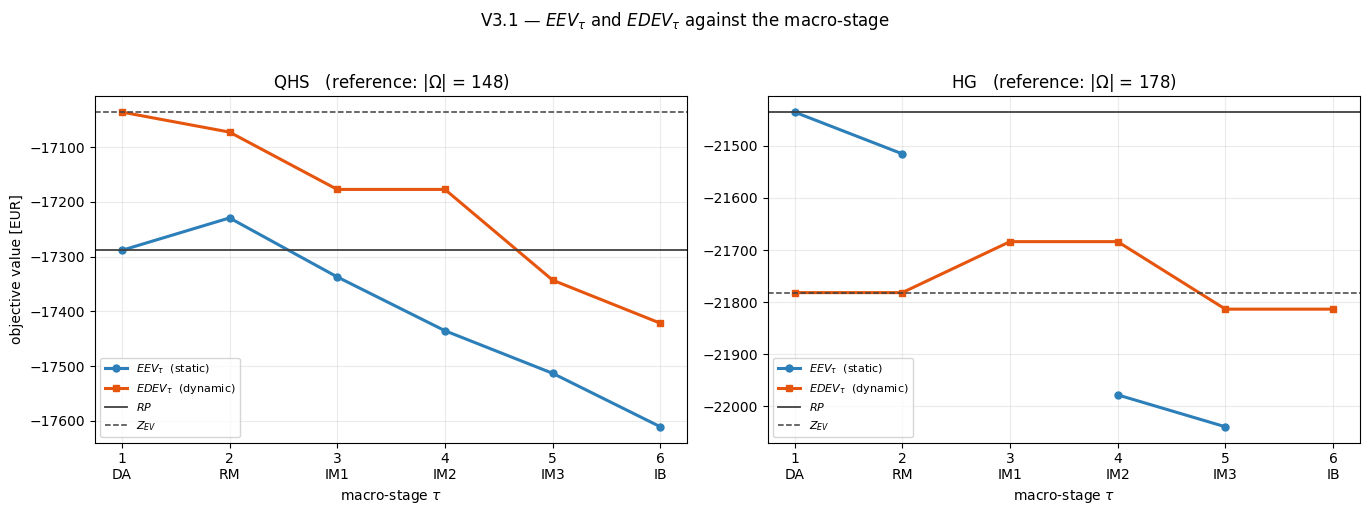

In [26]:
n_panels = len(FORMULATIONS)
fig, axes = plt.subplots(1, n_panels, figsize=(6.9 * n_panels, 5.0), squeeze=False)

for ax, form in zip(axes[0], FORMULATIONS):
    ref_run = REFERENCE_RUN[form]
    stat_f = static[static["formulation"] == form]
    dyn_f = dynamic[dynamic["formulation"] == form]

    # Only the reference configuration is drawn here. Overlaying every tree in EUR
    # levels spans the whole range of RP across trees and flattens the chain that is
    # the point of the figure; the spread of levels is V1.1's job and the spread of
    # the chains themselves is V1.5's and V3.2's.
    ref_stat = stat_f[stat_f["run_dir"] == ref_run].sort_values("tau")
    ref_dyn = dyn_f[dyn_f["run_dir"] == ref_run].sort_values("tau")
    ax.plot(ref_stat["tau"], ref_stat["EEV"], color=CHAIN_COLORS["static"],
            lw=2.2, marker="o", ms=5, label=r"$EEV_\tau$  (static)")
    ax.plot(ref_dyn["tau"], ref_dyn["EDEV"], color=CHAIN_COLORS["dynamic"],
            lw=2.2, marker="s", ms=5, label=r"$EDEV_\tau$  (dynamic)")

    ref_scalars = scalars.set_index("run_dir").loc[ref_run]
    ax.axhline(ref_scalars["RP"], color="0.25", lw=1.3, ls="-", label="$RP$")
    ax.axhline(ref_scalars["EV"], color="0.25", lw=1.1, ls="--", label="$Z_{EV}$")

    stage_axis(ax)
    ax.set_title(f"{form}   (reference: $|\\Omega|$ = {int(ref_scalars['pop_retained'])})")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

axes[0][0].set_ylabel("objective value [EUR]")
finish(fig, r"V3.1 — $EEV_\tau$ and $EDEV_\tau$ against the macro-stage")

In [27]:
# The chains' endpoints against RP and Z_EV, per run: the numbers behind V3.1.
levels = (dynamic.pivot_table(index="run_dir", columns="tau", values="EDEV")
          .add_prefix("EDEV_")
          .join(static.pivot_table(index="run_dir", columns="tau", values="EEV")
                .add_prefix("EEV_"))
          .join(scalars.set_index("run_dir")[["formulation", "pop_initial",
                                              "pop_retained", "RP", "EV"]]))
levels["EDEV_1_minus_EV"] = levels["EDEV_1"] - levels["EV"]
levels["EEV_1_equals_RP"] = (levels["EEV_1"] - levels["RP"]).abs() <= VALIDATION_TOL

cols = (["formulation", "pop_initial", "pop_retained", "RP", "EV"]
        + [f"EEV_{t}" for t in TAUS] + [f"EDEV_{t}" for t in TAUS]
        + ["EDEV_1_minus_EV", "EEV_1_equals_RP"])
levels.sort_values(["formulation", "pop_initial"])[cols].round(2)

,formulation,pop_initial,pop_retained,RP,EV,EEV_1,EEV_2,EEV_3,EEV_4,EEV_5,EEV_6,EDEV_1,EDEV_2,EDEV_3,EDEV_4,EDEV_5,EDEV_6,EDEV_1_minus_EV,EEV_1_equals_RP
run_dir,,,,,,,,,,,,,,,,,,,
FTC_20251031_20251130_c31_sc50_15min_same_ren,HG,50,30,-22533.48,-22578.09,-22533.48,-22667.33,NaN,NaN,NaN,-23062.42,-22578.09,-22802.51,-22919.52,-22919.52,-23072.55,-23228.15,0.00,True
FTC_20251031_20251130_c31_sc60_15min_same_ren,HG,60,36,-20822.96,-21287.61,-20822.96,-20967.80,NaN,NaN,NaN,NaN,-21287.61,-21287.61,-20983.07,-20983.07,-21189.37,-21189.37,0.00,True
FTC_20251031_20251130_c31_sc70_15min_same_ren,HG,70,38,-21773.89,-22191.26,-21773.89,-21909.38,-22231.80,-22429.14,-22580.92,-22617.83,-22191.26,-22191.26,-22090.44,-22090.44,-22203.24,-22376.16,0.00,True
FTC_20251031_20251130_c31_sc80_15min_same_ren,HG,80,39,-20698.99,-21022.45,-20698.99,-20805.35,-20961.02,-21256.12,-21412.18,-21446.36,-21022.45,-21022.45,-20851.25,-20851.25,-21008.49,-21131.81,0.00,True
FTC_20251031_20251130_c31_sc90_15min_same_ren,HG,90,44,-22911.97,-23396.64,-22911.97,-23138.17,-23409.78,-23638.81,-23778.59,-23847.27,-23396.64,-23396.64,-23381.04,-23381.04,-23505.38,-23505.38,0.00,True
FTC_20251031_20251130_c31_sc100_15min_same_ren,HG,100,37,-22344.80,-22828.93,-22344.80,-22726.59,-22889.64,-23009.39,-23108.31,-23160.83,-22828.93,-22828.93,-22804.23,-22804.23,-22996.01,-22996.01,0.00,True
FTC_20251031_20251130_c31_sc110_15min_same_ren,HG,110,46,-22273.82,-22813.16,-22273.82,-22636.98,-22820.50,-22982.25,-23189.67,-23248.71,-22813.16,-22813.16,-22752.53,-22752.53,-22905.38,-22886.53,0.00,True
FTC_20251031_20251130_c31_sc120_15min_same_ren,HG,120,51,-21767.68,-22202.21,-21767.68,-21942.00,-22127.29,-22417.80,-22570.41,-22645.34,-22202.21,-22202.21,-22072.08,-22072.08,-22288.58,-22288.58,0.00,True
FTC_20251031_20251130_c31_sc130_15min_same_ren,HG,130,52,-21673.73,-22043.97,-21673.73,-21974.11,-22122.37,-22264.37,-22343.27,-22409.45,-22043.97,-22043.97,-22044.15,-22044.15,-22218.10,-22143.45,0.00,True


## V3.2 — $VSS_\tau$ and $VSS^D_\tau$ side by side

The same information as differences from $RP$, which is the form the chapter's text uses.
The zero line is the whole story: the static chain lies above it by construction, the
dynamic chain lies below it because its guarantee does not hold here.

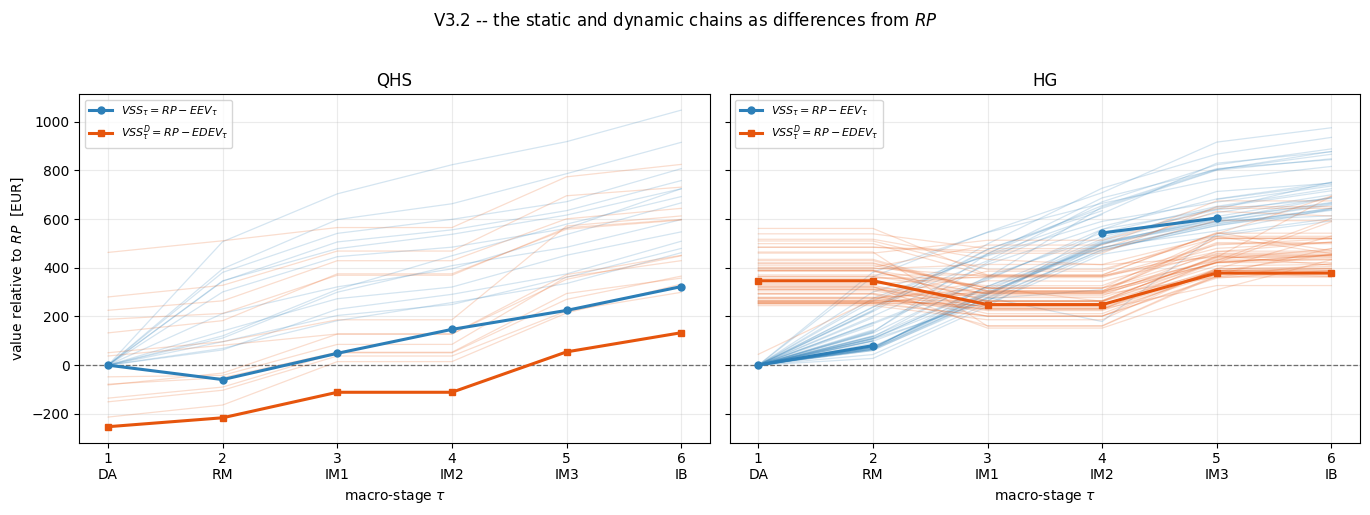

In [28]:
fig, axes = plt.subplots(1, n_panels, figsize=(6.9 * n_panels, 5.0), squeeze=False,
                         sharey=True)

for ax, form in zip(axes[0], FORMULATIONS):
    ref_run = REFERENCE_RUN[form]
    stat_f = static[static["formulation"] == form]
    dyn_f = dynamic[dynamic["formulation"] == form]

    plot_per_run_lines(ax, stat_f, "VSS", form, color=CHAIN_COLORS["static"],
                       alpha=0.20, lw=0.9)
    plot_per_run_lines(ax, dyn_f, "VSSD", form, color=CHAIN_COLORS["dynamic"],
                       alpha=0.20, lw=0.9)

    ref_stat = stat_f[stat_f["run_dir"] == ref_run].sort_values("tau")
    ref_dyn = dyn_f[dyn_f["run_dir"] == ref_run].sort_values("tau")
    ax.plot(ref_stat["tau"], ref_stat["VSS"], color=CHAIN_COLORS["static"],
            lw=2.2, marker="o", ms=5, label=r"$VSS_\tau = RP - EEV_\tau$")
    ax.plot(ref_dyn["tau"], ref_dyn["VSSD"], color=CHAIN_COLORS["dynamic"],
            lw=2.2, marker="s", ms=5, label=r"$VSS^D_\tau = RP - EDEV_\tau$")

    stage_axis(ax)
    zero_line(ax)
    ax.set_title(form)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

axes[0][0].set_ylabel("value relative to $RP$  [EUR]")
finish(fig, r"V3.2 -- the static and dynamic chains as differences from $RP$")


## V3.3 -- retired: decomposition with $EDEV^{\mathrm{rec}}_2$

This item decomposed the dynamic gap $EDEV_2 - RP$ using the supplementary
comparator $EDEV^{\mathrm{rec}}_2$ / $VSS^{D,\mathrm{rec}}_2$ of the (commented-out)
`def:edev2rec`. That comparator has been removed from the VSS pipeline
(`run_vssd.py`) and the current data drop no longer computes it for QHS at all;
per the chapter's scope, it is not presented anywhere in Section 4.3. The item
is kept here, collapsed to this note, rather than deleted outright, so the
notebook's own record of what V3.3 used to show is not lost.


# (cell retired together with V3.3 above -- see the note there)


## V3.4 — Where stochasticity matters

The reporting frame's fourth item: *"at which macro-stages the information is most
valuable, read from the shape of the static chain."*

The static chain is read as increments. $VSS_\tau - VSS_{\tau-1} = EEV_{\tau-1} - EEV_\tau$
is the cost of additionally committing macro-stage $\tau-1$ from the average forecast,
having already committed everything before it — and `prop:static-guarantee` makes every
increment non-negative. Expressed as a share of the end-of-chain value, the increments
form a decomposition of $VSS_{T}$ across the six market sessions, so the largest bar
names the session at which entering with an averaged decision costs most.

$VSS_1 = 0$ by construction, so the first increment is attached to $\tau = 2$.

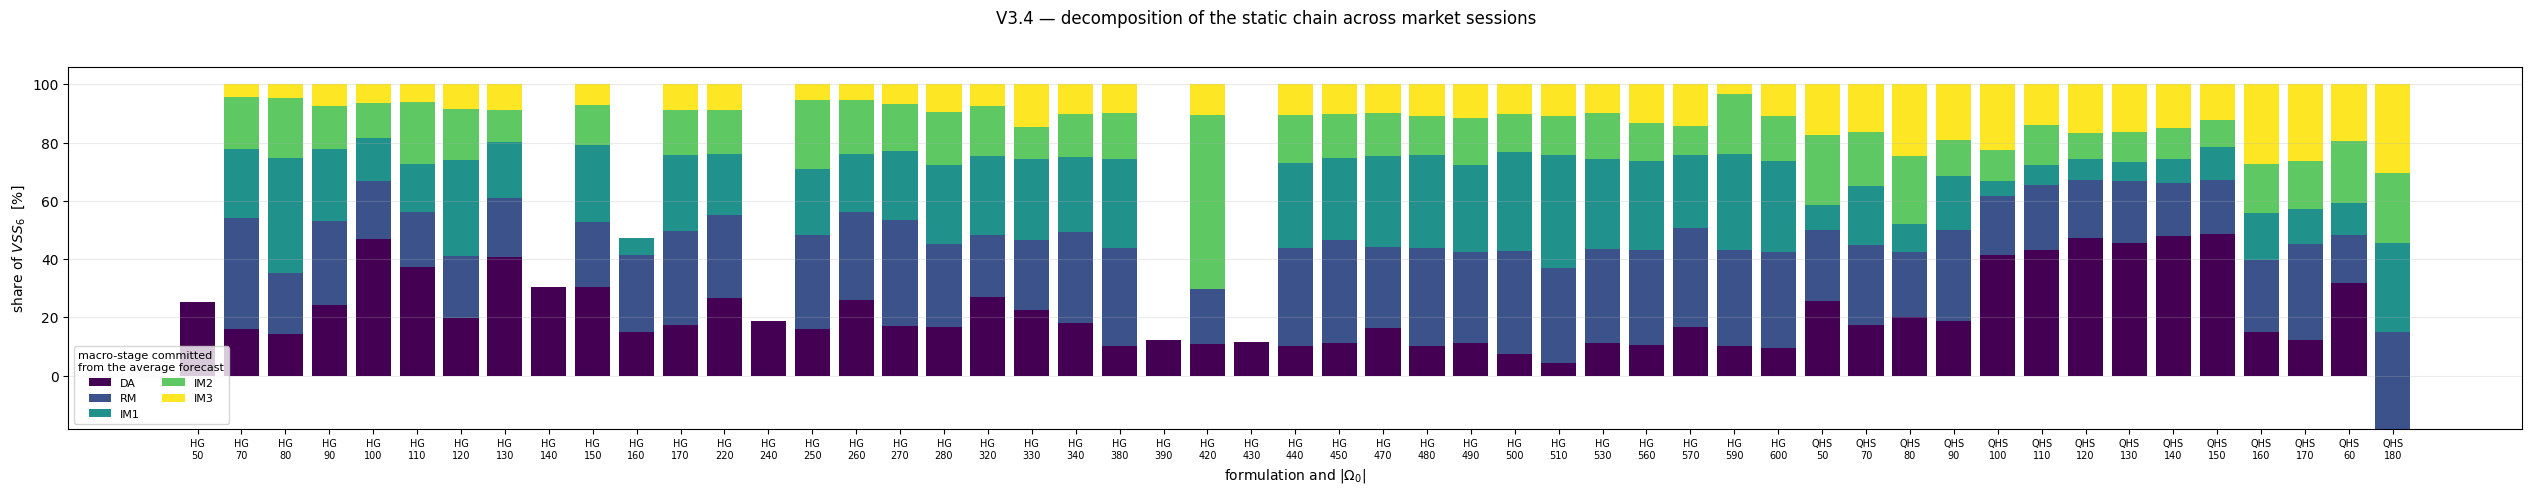

Mean share of the end-of-chain VSS contributed by committing each macro-stage [%]
committed_stage    DA    RM   IM1   IM2   IM3
formulation                                  
HG               18.4  29.5  25.4  17.1   8.9
QHS              28.3  23.8  12.3  15.8  19.9

Macro-stage carrying the largest single increment, per run:
                               runs
formulation largest_increment      
HG          DA                    9
            IM1                   6
            IM2                   1
            RM                   21
QHS         DA                    8
            IM3                   2
            RM                    4


In [29]:
increments = static.sort_values(["run_dir", "tau"]).copy()
increments["delta_VSS"] = increments.groupby("run_dir")["VSS"].diff()
increments = increments.dropna(subset=["delta_VSS"])
increments["delta_share_of_end"] = 100.0 * increments["delta_VSS"] / increments["run_dir"].map(
    static[static["tau"] == TAU_LAST].set_index("run_dir")["VSS"])

# The increment at tau is the cost of committing macro-stage tau-1 from the average.
increments["committed_stage"] = increments["tau"].map(lambda t: MACRO_STAGES[t - 2])

pivot = increments.pivot_table(index=["formulation", "pop_initial"],
                               columns="committed_stage", values="delta_share_of_end")
pivot = pivot[[s for s in MACRO_STAGES if s in pivot.columns]]

fig, ax = plt.subplots(figsize=(max(FIGSIZE_SINGLE[0], 0.42 * len(pivot) + 4), 4.8))
bottom = np.zeros(len(pivot))
cmap = plt.get_cmap("viridis")
for i, stage in enumerate(pivot.columns):
    vals = pivot[stage].to_numpy()
    ax.bar(np.arange(len(pivot)), vals, bottom=bottom,
           color=cmap(i / max(len(pivot.columns) - 1, 1)), label=stage)
    bottom += vals

ax.set_xticks(np.arange(len(pivot)))
ax.set_xticklabels([f"{f}\n{p}" for f, p in pivot.index], fontsize=7)
ax.set_xlabel(r"formulation and $|\Omega_0|$")
ax.set_ylabel(rf"share of $VSS_{{{TAU_LAST}}}$  [%]")
ax.grid(alpha=0.25, axis="y")
ax.legend(fontsize=8, title="macro-stage committed\nfrom the average forecast",
          title_fontsize=8, ncol=2)
finish(fig, r"V3.4 — decomposition of the static chain across market sessions")

print("Mean share of the end-of-chain VSS contributed by committing each macro-stage [%]")
print(pivot.groupby(level="formulation").mean().round(1).to_string())
print()
dominant = pivot.idxmax(axis=1).rename("largest_increment")
print("Macro-stage carrying the largest single increment, per run:")
print(dominant.reset_index().groupby(["formulation", "largest_increment"])
      .size().rename("runs").to_frame().to_string())

## V3.5 — Every value beside the mass discarded to obtain it

`subsec:vss-exclusion` requires this pairing, not merely the availability of both
numbers. The table below is the chain's values and their excluded mass in the same row,
and the figure places the mass directly beneath the chain it qualifies.

A value on a row with a non-zero mass is a value computed on a *different problem* from
its neighbours: the surviving scenarios (static chain) or groups (dynamic chain) have
been renormalised to unit probability. Where the mass is non-negligible, the monotonicity
of the affected chain may break for that reason alone, and V3.7 reads any such break in
that light.

In [30]:
paired = (static[["formulation", "run_dir", "pop_initial", "tau", "macro_stage",
                  "EEV", "VSS", "excluded_mass"]]
          .rename(columns={"excluded_mass": "static_excluded_mass"})
          .merge(dynamic[["run_dir", "tau", "EDEV", "VSSD", "excluded_mass"]]
                 .rename(columns={"excluded_mass": "dynamic_excluded_mass"}),
                 on=["run_dir", "tau"])
          .sort_values(["formulation", "pop_initial", "tau"]))

has_exclusion = paired[(paired["static_excluded_mass"] > 0)
                       | (paired["dynamic_excluded_mass"] > 0)]
if has_exclusion.empty:
    print("No value in either chain was obtained after discarding probability mass.")
    shown = paired
else:
    print(f"{len(has_exclusion)} of {len(paired)} (run, stage) values were obtained "
          f"after discarding probability mass; those rows are shown first.")
    shown = pd.concat([has_exclusion, paired.drop(has_exclusion.index)])

shown.round(4).reset_index(drop=True).head(40)

105 of 414 (run, stage) values were obtained after discarding probability mass; those rows are shown first.


,formulation,run_dir,pop_initial,tau,macro_stage,EEV,VSS,static_excluded_mass,EDEV,VSSD,dynamic_excluded_mass
0,HG,FTC_20251031_20251130_c31_sc50_15min_same_ren,50,3,IM1,NaN,NaN,1.0000,-22919.5152,386.0392,0.0000
1,HG,FTC_20251031_20251130_c31_sc50_15min_same_ren,50,4,IM2,NaN,NaN,1.0000,-22919.5152,386.0392,0.0000
2,HG,FTC_20251031_20251130_c31_sc50_15min_same_ren,50,5,IM3,NaN,NaN,1.0000,-23072.5456,539.0696,0.0000
3,HG,FTC_20251031_20251130_c31_sc50_15min_same_ren,50,6,IB,-23062.4229,528.9469,0.0800,-23228.1518,694.6758,0.0000
4,HG,FTC_20251031_20251130_c31_sc60_15min_same_ren,60,3,IM1,NaN,NaN,1.0000,-20983.0738,160.1109,0.0000
5,HG,FTC_20251031_20251130_c31_sc60_15min_same_ren,60,4,IM2,NaN,NaN,1.0000,-20983.0738,160.1109,0.0000
6,HG,FTC_20251031_20251130_c31_sc60_15min_same_ren,60,5,IM3,NaN,NaN,1.0000,-21189.3650,366.4021,0.0000
7,HG,FTC_20251031_20251130_c31_sc60_15min_same_ren,60,6,IB,NaN,NaN,1.0000,-21189.3650,366.4021,0.0000
8,HG,FTC_20251031_20251130_c31_sc110_15min_same_ren,110,6,IB,-23248.7134,974.8888,0.0000,-22886.5281,612.7035,0.0091
9,HG,FTC_20251031_20251130_c31_sc130_15min_same_ren,130,6,IB,-22409.4493,735.7223,0.0000,-22143.4550,469.7280,0.0462


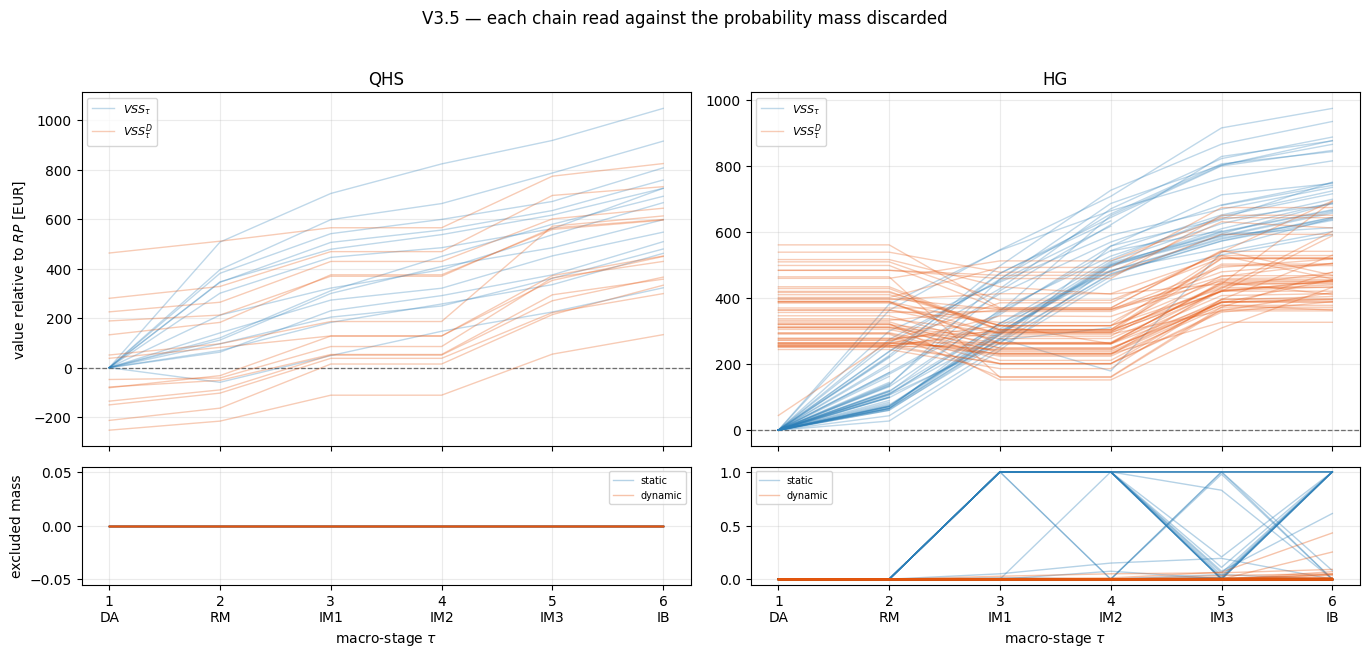

In [31]:
# Chain and its excluded mass on shared axes, per formulation.
fig, axes = plt.subplots(2, n_panels, figsize=(6.9 * n_panels, 6.4), squeeze=False,
                         sharex="col", gridspec_kw={"height_ratios": [3, 1]})

for col, form in enumerate(FORMULATIONS):
    ax_top, ax_bot = axes[0][col], axes[1][col]

    plot_per_run_lines(ax_top, static[static["formulation"] == form], "VSS", form,
                       color=CHAIN_COLORS["static"], alpha=0.30, lw=1.0,
                       label=r"$VSS_\tau$")
    plot_per_run_lines(ax_top, dynamic[dynamic["formulation"] == form], "VSSD", form,
                       color=CHAIN_COLORS["dynamic"], alpha=0.30, lw=1.0,
                       label=r"$VSS^D_\tau$")
    zero_line(ax_top)
    ax_top.set_title(form)
    ax_top.grid(alpha=0.25)
    ax_top.legend(fontsize=8)

    plot_per_run_lines(ax_bot, static[static["formulation"] == form], "excluded_mass",
                       form, color=CHAIN_COLORS["static"], alpha=0.35, lw=1.0,
                       label="static")
    plot_per_run_lines(ax_bot, dynamic[dynamic["formulation"] == form], "excluded_mass",
                       form, color=CHAIN_COLORS["dynamic"], alpha=0.35, lw=1.0,
                       label="dynamic")
    stage_axis(ax_bot)
    ax_bot.grid(alpha=0.25)
    ax_bot.legend(fontsize=7)

axes[0][0].set_ylabel("value relative to $RP$ [EUR]")
axes[1][0].set_ylabel("excluded mass")
finish(fig, "V3.5 — each chain read against the probability mass discarded")

## V3.6 — Why $EDEV_1 \ne Z_{EV}$: the group decomposition at $\tau = 1$

`tab:props` records $EDEV_1 = Z_{EV}$ as **false here**, and `subsec:vss-mismatch` gives
the reason: the community does not submit a single day-ahead quantity but a **bid curve**,
a schedule of quantities as a function of the clearing price. Since the clearing price is
the stage-1 random variable, the curve is represented by letting $e^{DA\pm}$ vary across
scenarios — that is, by *not* equating them at the root. The stage-1 clustering therefore
partitions $\Omega$ into $\lvert\mathcal{G}_1\rvert \ne 1$ groups, and
$EDEV_1 = \sum_{g} w^g Z^g_{EV}$ is a weighted mean of that many independent optima
rather than the value of one averaged problem.

This item shows the decomposition directly, from the per-group trace
`[t= g= |Omega_g|= w=] status= Z_EV_g=` that `run_vssd.py` writes to
`<run>/DA/vssd_run_all.log`.

> **Data status: partially computable, and provenance-dependent.**
> The trace is written by the orchestrator as it goes, so a run that terminated early
> leaves a *truncated* log: complete for the macro-stages it finished, absent for the
> rest. The cell below reports, per log, how many stages are complete and whether the
> $EDEV_\tau$ it reconstructs matches the published CSV — so a truncated or stale log is
> visible rather than silently plotted. Only stages that reconcile are drawn.
> When the logs are complete this item extends to every macro-stage with no edit.

In [32]:
# ---------------------------------------------------------------------------
# Per-group trace parser (V3.6). Tolerant of truncation: a run that stopped early
# leaves complete stages followed by an incomplete or absent one.
# ---------------------------------------------------------------------------
GROUP_LINE_RE = re.compile(
    r"\[t=(?P<tau>\d+)\s+g=(?P<group>\d+)\s+\|Omega_g\|=(?P<size>\d+)\s+"
    r"w=(?P<weight>[\d.eE+-]+)\]\s+status=(?P<status>\S+)"
    r"(?:\s+Z_EV_g=(?P<z_ev>-?[\d.eE+-]+))?")


def parse_group_log(path, run_dir, formulation):
    if not os.path.exists(path):
        return pd.DataFrame()
    with open(path, errors="ignore") as fh:
        text = fh.read()
    rows = [{"run_dir": run_dir, "formulation": formulation,
             "tau": int(m.group("tau")), "group_id": int(m.group("group")),
             "omega_size": int(m.group("size")), "weight": float(m.group("weight")),
             "status": m.group("status"),
             "Z_EV_g": float(m.group("z_ev")) if m.group("z_ev") else np.nan}
            for m in GROUP_LINE_RE.finditer(text)]
    df = pd.DataFrame(rows)
    if not df.empty:
        # A stage can be logged more than once if the orchestrator was re-run into
        # the same file; keep the last occurrence of each (tau, group).
        df = df.drop_duplicates(subset=["tau", "group_id"], keep="last")
    return df


group_frames = [parse_group_log(r["group_log_path"], r["run_dir"], r["formulation"])
                for r in scalars.to_dict("records") if r["has_group_log"]]
groups = (pd.concat(group_frames, ignore_index=True) if group_frames
          else pd.DataFrame(columns=["run_dir", "formulation", "tau", "group_id",
                                     "omega_size", "weight", "status", "Z_EV_g"]))

if groups.empty:
    print("No per-group trace found. V3.6 is not computable from the present data;\n"
          "it needs <run>/DA/vssd_run_all.log, which run_vssd.py writes when the\n"
          "dynamic chain is run with its output redirected to that file.")
else:
    print(f"per-group traces parsed for {groups['run_dir'].nunique()} run(s): "
          f"{sorted(groups['run_dir'].unique())}")

No per-group trace found. V3.6 is not computable from the present data;
it needs <run>/DA/vssd_run_all.log, which run_vssd.py writes when the
dynamic chain is run with its output redirected to that file.


In [33]:
# ---------------------------------------------------------------------------
# Reconcile each logged stage against the published EDEV_tau before drawing it.
# A stage is complete when the solved groups' weights account for essentially all
# of the probability mass; renormalisation follows edev_vssd.compute_edev_t.
# ---------------------------------------------------------------------------
def reconstruct_edev(stage_groups):
    solved = stage_groups.dropna(subset=["Z_EV_g"])
    total_weight = solved["weight"].sum()
    if total_weight <= 0:
        return np.nan, 0.0
    return float((solved["weight"] / total_weight * solved["Z_EV_g"]).sum()), float(total_weight)


if groups.empty:
    group_audit = pd.DataFrame()
else:
    published = dynamic.set_index(["run_dir", "tau"])["EDEV"]
    audit_rows = []
    for (run_dir, tau), stage_groups in groups.groupby(["run_dir", "tau"]):
        edev_hat, weight = reconstruct_edev(stage_groups)
        edev_pub = published.get((run_dir, tau), np.nan)
        audit_rows.append({
            "run_dir": run_dir, "tau": tau,
            "n_groups": len(stage_groups),
            "n_solved": int(stage_groups["Z_EV_g"].notna().sum()),
            "weight_covered": weight,
            "EDEV_reconstructed": edev_hat,
            "EDEV_published": edev_pub,
            "abs_diff": abs(edev_hat - edev_pub) if pd.notna(edev_pub) else np.nan,
            "rel_diff": (abs(edev_hat - edev_pub) / abs(edev_pub)
                         if pd.notna(edev_pub) and edev_pub else np.nan),
        })
    group_audit = pd.DataFrame(audit_rows).sort_values(["run_dir", "tau"])
    # A stage is usable when its groups cover essentially all the probability mass
    # AND its reconstruction matches the published EDEV_tau within GROUP_LOG_REL_TOL.
    # The tolerance is relative and sized to the log's own four-decimal printing of
    # the group weights, not to solver accuracy -- see the setup cell.
    group_audit["stage_complete"] = group_audit["weight_covered"] > 0.99
    group_audit["reconciles_with_csv"] = group_audit["rel_diff"] <= GROUP_LOG_REL_TOL
    group_audit["usable"] = group_audit["stage_complete"] & group_audit["reconciles_with_csv"]
    print("Per-stage audit of the group traces (only `usable` stages are plotted):")

group_audit.round(4).reset_index(drop=True) if not groups.empty else "no group traces"

'no group traces'

In [34]:
if groups.empty or group_audit.empty or not group_audit["usable"].any():
    print("No group-trace stage is both complete and reconciled; V3.6 renders nothing.")
else:
    usable = group_audit[group_audit["usable"]]
    tau_to_plot = int(usable["tau"].min())          # tau=1 wherever available
    keys = set(map(tuple, usable.loc[usable["tau"] == tau_to_plot,
                                     ["run_dir", "tau"]].to_numpy()))
    sel = groups[[(r, t) in keys for r, t in zip(groups["run_dir"], groups["tau"])]]

    fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
    for run_dir, grp in sel.groupby("run_dir"):
        form = grp["formulation"].iloc[0]
        ax.scatter(grp["weight"], grp["Z_EV_g"], s=18 + 6 * grp["omega_size"],
                   color=COLORS[form], alpha=0.65, edgecolor="white", lw=0.6,
                   label=f"{form}: {grp['group_id'].nunique()} groups")
        row = scalars.set_index("run_dir").loc[run_dir]
        ax.axhline(row["EV"], color="0.25", ls="--", lw=1.2, label="$Z_{EV}$")
        edev_row = dynamic[(dynamic["run_dir"] == run_dir)
                           & (dynamic["tau"] == tau_to_plot)].iloc[0]
        ax.axhline(edev_row["EDEV"], color=CHAIN_COLORS["dynamic"], ls="-", lw=1.6,
                   label=rf"$EDEV_{tau_to_plot}$")

    ax.set_xlabel(r"group weight $w^g$")
    ax.set_ylabel(r"$Z^g_{EV}$  [EUR]")
    ax.grid(alpha=0.25)
    handles, labels = ax.get_legend_handles_labels()
    seen, uniq = set(), []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l)
            uniq.append((h, l))
    ax.legend(*zip(*uniq), fontsize=8)
    finish(fig, rf"V3.6 — group-conditional optima at $\tau$ = {tau_to_plot} "
                r"(marker size $\propto |\Omega_g|$)")

    spread = (sel.groupby(["formulation", "run_dir"])
              .agg(n_groups=("group_id", "nunique"),
                   Z_EV_g_min=("Z_EV_g", "min"), Z_EV_g_max=("Z_EV_g", "max"),
                   weight_sum=("weight", "sum")))
    print("Dispersion of the group-conditional optima that EDEV averages over:")
    print(spread.round(2).to_string())

No group-trace stage is both complete and reconciled; V3.6 renders nothing.


> **What the spread shows.** Each group solves a deterministic problem against *its
> own* conditional forecast, with no visibility of the other groups — that blindness is
> exactly the mechanism `prop:vssd-failure` invokes. A wide spread of $Z^g_{EV}$ around
> $Z_{EV}$, whose weighted mean lands *above* $Z_{EV}$, is the concrete reason
> $EDEV_1 \ne Z_{EV}$ and the reason the dynamic chain begins on the optimistic side of
> $RP$.

## V3.7 — Verification of the properties audited in `tab:props`

The chapter closes on this: *"verification of the theoretical properties audited in
Table~\ref{tab:props}: whether the guaranteed monotonicity of the static chain is
observed, and whether the dynamic measure is non-negative."*

The table below evaluates each property per formulation at `validation.py`'s own
tolerance (`DEFAULT_TOL = 1e-6`), and carries the **expected** status from `tab:props`
beside the **observed** one — because several of these properties are expected to fail,
and a table that reported only pass/fail would misrepresent the methods chapter.

> **Provenance of this table.** `validation.py` emits its report to stdout and it is not
> persisted anywhere under `results/`. The predicates below are therefore recomputed here
> from the published CSVs, following `validation.py` statement by statement. They are a
> faithful reimplementation, not a recovered artefact.

| `tab:props` row | Statement | Status there |
|---|---|---|
| Prop. 1, Cor. 1 | $EEV_{\tau+1} \le EEV_\tau$, $0 \le VSS_\tau \le VSS_{\tau+1}$ | **Guaranteed** |
| Prop. 2 | $VSS_\tau \le EV - EEV_\tau$ | **Not applicable** (stochastic objective coefficients) |
| Prop. 4 | $EDEV_{\tau+1} \le EDEV_\tau$ (Jensen) | **Not applicable** — checked informationally |
| Prop. 5 | $VSS^D \ge 0$ | **Not guaranteed** |
| Prop. 6 | $EDEV_{\tau+1} \le EDEV_\tau$ (feasibility) | **Not guaranteed** |
| Prop. 7 | $0 \le VSS^D_\tau \le VSS^D_{\tau+1}$ | **Not guaranteed** |
| — | $EDEV_1 = EV$ | **False here** |
| — | $EDEV_2 = EDEV_1$ | **Expected** |

> **Two rows share one predicate.** Propositions 4 and 6 both assert
> $EDEV_{\tau+1} \le EDEV_\tau$ and will therefore always return the same verdict.
> They are kept as separate rows because `tab:props` and `validation.py` keep them
> separate: they differ in *why* the inequality is expected (Jensen versus feasibility)
> and in status — Proposition 4 is checked informationally only, since this model's
> objective coefficients are the stochastic market prices and its hypothesis does not
> hold. A shared verdict is the correct output, not a duplicated row.
>
> **Two tolerances are in play.** Every inequality uses `validation.py`'s own absolute
> `DEFAULT_TOL = 1e-6`. The three equality identities use the scale-aware comparator of
> the setup cell instead, because on quantities of order $10^4$ EUR an absolute $10^{-6}$
> threshold tests the eleventh significant digit and would report ordinary solver float
> noise as a failed theorem.

In [35]:
# ---------------------------------------------------------------------------
# tab:props verification (V3.7). One predicate per row of the methods table,
# evaluated per run and then aggregated per formulation.
# ---------------------------------------------------------------------------
EXPECTED_STATUS = {
    "Prop. 1 / Cor. 1: EEV_{t+1} <= EEV_t": "Guaranteed",
    "Prop. 1 / Cor. 1: VSS_t >= 0": "Guaranteed",
    "Prop. 1 / Cor. 1: VSS_t <= VSS_{t+1}": "Guaranteed",
    "Prop. 2: VSS_t <= EV - EEV_t": "Not applicable",
    "Prop. 4 (informational): EDEV_{t+1} <= EDEV_t": "Not applicable",
    "Prop. 5: VSSD >= 0": "Not guaranteed",
    "Prop. 6: EDEV_{t+1} <= EDEV_t": "Not guaranteed",
    "Prop. 7: VSSD_t >= 0": "Not guaranteed",
    "Prop. 7: VSSD_t <= VSSD_{t+1}": "Not guaranteed",
    "EDEV_1 == EV": "False here",
    "EDEV_2 == EDEV_1": "Expected",
    "EEV_1 == RP (by construction)": "Definition",
}


def check_run(run_dir):
    """Every tab:props predicate for one run. Returns {property: (n_ok, n_tested)}."""
    s = static[static["run_dir"] == run_dir].set_index("tau").sort_index()
    d = dynamic[dynamic["run_dir"] == run_dir].set_index("tau").sort_index()
    sc = scalars.set_index("run_dir").loc[run_dir]
    tol = VALIDATION_TOL
    out = {}

    def record(name, results):
        out[name] = (int(sum(results)), len(results))

    # The three equality identities use the scale-aware comparator; every
    # inequality below uses validation.py's own absolute tolerance.
    record("EEV_1 == RP (by construction)",
           [equal_within_scale(s.loc[1, "EEV"], sc["RP"])])
    record("Prop. 1 / Cor. 1: EEV_{t+1} <= EEV_t",
           [s.loc[t + 1, "EEV"] <= s.loc[t, "EEV"] + tol for t in TAUS[:-1]])
    record("Prop. 1 / Cor. 1: VSS_t >= 0", [s.loc[t, "VSS"] >= -tol for t in TAUS])
    record("Prop. 1 / Cor. 1: VSS_t <= VSS_{t+1}",
           [s.loc[t + 1, "VSS"] >= s.loc[t, "VSS"] - tol for t in TAUS[:-1]])
    # Prop. 2 is Not applicable in tab:props; evaluated to show whether the bound it
    # would have supplied is in fact respected.
    record("Prop. 2: VSS_t <= EV - EEV_t",
           [s.loc[t, "VSS"] <= (sc["EV"] - s.loc[t, "EEV"]) + tol for t in TAUS])
    record("Prop. 4 (informational): EDEV_{t+1} <= EDEV_t",
           [d.loc[t + 1, "EDEV"] <= d.loc[t, "EDEV"] + tol for t in TAUS[:-1]])
    record("Prop. 5: VSSD >= 0", [sc["VSSD"] >= -tol])
    record("Prop. 6: EDEV_{t+1} <= EDEV_t",
           [d.loc[t + 1, "EDEV"] <= d.loc[t, "EDEV"] + tol for t in TAUS[:-1]])
    record("Prop. 7: VSSD_t >= 0", [d.loc[t, "VSSD"] >= -tol for t in TAUS])
    record("Prop. 7: VSSD_t <= VSSD_{t+1}",
           [d.loc[t + 1, "VSSD"] >= d.loc[t, "VSSD"] - tol for t in TAUS[:-1]])
    record("EDEV_1 == EV", [equal_within_scale(d.loc[1, "EDEV"], sc["EV"])])
    record("EDEV_2 == EDEV_1", [equal_within_scale(d.loc[2, "EDEV"], d.loc[1, "EDEV"])])
    return out


check_rows = []
for rec in scalars.to_dict("records"):
    for prop, (n_ok, n_tested) in check_run(rec["run_dir"]).items():
        check_rows.append({"formulation": rec["formulation"], "run_dir": rec["run_dir"],
                           "property": prop, "n_ok": n_ok, "n_tested": n_tested,
                           "all_ok": n_ok == n_tested})

checks = pd.DataFrame(check_rows)
print(f"{checks['property'].nunique()} properties x {checks['run_dir'].nunique()} runs "
      f"= {len(checks)} property-run verdicts")

12 properties x 69 runs = 828 property-run verdicts


In [36]:
# Aggregate to the table the chapter prints: one row per property, one column pair
# per formulation.
props = (checks.groupby(["property", "formulation"])
         .agg(runs=("run_dir", "size"), runs_passing=("all_ok", "sum"),
              checks_ok=("n_ok", "sum"), checks_total=("n_tested", "sum"))
         .reset_index())
props["verdict"] = np.where(props["runs_passing"] == props["runs"], "holds",
                            np.where(props["runs_passing"] == 0, "fails", "mixed"))

tab_props = props.pivot(index="property", columns="formulation",
                        values=["verdict", "runs_passing", "runs"])
tab_props.columns = [f"{form}.{field}" for field, form in tab_props.columns]
tab_props.insert(0, "expected (tab:props)",
                 pd.Series(EXPECTED_STATUS).reindex(tab_props.index))
tab_props = tab_props.reindex([p for p in EXPECTED_STATUS if p in tab_props.index])

print("V3.7 -- tab:props verification")
tab_props

V3.7 -- tab:props verification


,expected (tab:props),HG.verdict,QHS.verdict,HG.runs_passing,QHS.runs_passing,HG.runs,QHS.runs
property,,,,,,,
Prop. 1 / Cor. 1: EEV_{t+1} <= EEV_t,Guaranteed,mixed,mixed,30,13,55,14
Prop. 1 / Cor. 1: VSS_t >= 0,Guaranteed,mixed,mixed,31,13,55,14
Prop. 1 / Cor. 1: VSS_t <= VSS_{t+1},Guaranteed,mixed,mixed,30,13,55,14
Prop. 2: VSS_t <= EV - EEV_t,Not applicable,fails,mixed,0,7,55,14
Prop. 4 (informational): EDEV_{t+1} <= EDEV_t,Not applicable,mixed,holds,2,14,55,14
Prop. 5: VSSD >= 0,Not guaranteed,holds,holds,55,14,55,14
Prop. 6: EDEV_{t+1} <= EDEV_t,Not guaranteed,mixed,holds,2,14,55,14
Prop. 7: VSSD_t >= 0,Not guaranteed,holds,mixed,55,7,55,14
Prop. 7: VSSD_t <= VSSD_{t+1},Not guaranteed,mixed,holds,2,14,55,14


In [37]:
# Every individual failure, named. A property that fails everywhere is a finding;
# a property that fails in one run of many is something to look at.
failures = checks[~checks["all_ok"]].merge(
    scalars[["run_dir", "pop_initial", "pop_retained"]], on="run_dir")
failures["expected"] = failures["property"].map(EXPECTED_STATUS)
failures = failures.sort_values(["property", "formulation", "pop_initial"])

if failures.empty:
    print("Every property holds in every run.")
else:
    print(f"{len(failures)} property-run verdicts are negative. "
          "The `expected` column says whether tab:props predicted it.")

failures[["property", "expected", "formulation", "pop_initial", "pop_retained",
          "n_ok", "n_tested"]].reset_index(drop=True)

321 property-run verdicts are negative. The `expected` column says whether tab:props predicted it.


,property,expected,formulation,pop_initial,pop_retained,n_ok,n_tested
0,EDEV_1 == EV,False here,QHS,50,46,0,1
1,EDEV_2 == EDEV_1,Expected,HG,50,30,0,1
2,EDEV_2 == EDEV_1,Expected,QHS,50,46,0,1
3,EDEV_2 == EDEV_1,Expected,QHS,60,51,0,1
4,EDEV_2 == EDEV_1,Expected,QHS,70,60,0,1
...,...,...,...,...,...,...,...
316,Prop. 7: VSSD_t >= 0,Not guaranteed,QHS,80,75,4,6
317,Prop. 7: VSSD_t >= 0,Not guaranteed,QHS,90,88,4,6
318,Prop. 7: VSSD_t >= 0,Not guaranteed,QHS,160,140,4,6
319,Prop. 7: VSSD_t >= 0,Not guaranteed,QHS,170,141,4,6


In [38]:
# Cross-reference the dynamic chain's monotonicity failures against the excluded
# mass, since renormalising after an exclusion can itself lift EDEV_{t+1} above
# EDEV_t without any modelling defect.
mono = dynamic.sort_values(["run_dir", "tau"]).copy()
mono["EDEV_prev"] = mono.groupby("run_dir")["EDEV"].shift(1)
mono["excluded_prev"] = mono.groupby("run_dir")["excluded_mass"].shift(1)
mono = mono.dropna(subset=["EDEV_prev"])
mono["violates_prop6"] = mono["EDEV"] > mono["EDEV_prev"] + VALIDATION_TOL
mono["mass_changed_here"] = (mono["excluded_mass"] - mono["excluded_prev"]).abs() > 0
mono["rise_EUR"] = mono["EDEV"] - mono["EDEV_prev"]
mono["rise_rel"] = mono["rise_EUR"] / mono["EDEV_prev"].abs()
# A step that clears validation.py's absolute tolerance but not the scale-aware one
# is two numerically indistinguishable values, not a violated theorem. Separating
# the two matters: the chapter should report the material violations, not the ties.
mono["numerically_tied"] = [equal_within_scale(a, b)
                            for a, b in zip(mono["EDEV"], mono["EDEV_prev"])]

viol = mono[mono["violates_prop6"]]
if viol.empty:
    print("Proposition 6 (EDEV_{t+1} <= EDEV_t) is not violated in any run.")
else:
    cols = ["formulation", "run_dir", "tau", "macro_stage", "EDEV_prev", "EDEV",
            "rise_EUR", "rise_rel", "numerically_tied", "excluded_prev",
            "excluded_mass", "mass_changed_here"]
    print("Steps failing Proposition 6 at validation.py's absolute tolerance:")
    print(viol[cols].to_string(index=False,
                               float_format=lambda v: f"{v:.4g}"))
    material = viol[~viol["numerically_tied"]]
    print(f"\n{len(viol)} steps fail the absolute test; {len(material)} of them are "
          f"material (the rest are numerically tied values).")
    if not material.empty:
        coincide = int(material["mass_changed_here"].sum())
        print(f"{coincide} of the {len(material)} material violations occur at a step "
              f"where the excluded probability mass changes.")

Steps failing Proposition 6 at validation.py's absolute tolerance:
formulation                                        run_dir  tau macro_stage  EDEV_prev       EDEV  rise_EUR  rise_rel  numerically_tied  excluded_prev  excluded_mass  mass_changed_here
         HG FTC_20251031_20251130_c31_sc100_15min_same_ren    2          RM -2.283e+04 -2.283e+04 9.736e-06 4.265e-10              True              0              0              False
         HG FTC_20251031_20251130_c31_sc100_15min_same_ren    3         IM1 -2.283e+04  -2.28e+04      24.7  0.001082             False              0              0              False
         HG FTC_20251031_20251130_c31_sc110_15min_same_ren    3         IM1 -2.281e+04 -2.275e+04     60.62  0.002657             False              0              0              False
         HG FTC_20251031_20251130_c31_sc110_15min_same_ren    6          IB -2.291e+04 -2.289e+04     18.85 0.0008229             False              0       0.009091               True
        

## V3.8 — Constraints violated and infeasibility margins

> ### ❌ NOT COMPUTABLE FROM THE PRESENT DATA — kept here so the gap is visible
>
> The chapter's reporting frame asks for *"which constraints were implicated in the
> infeasibilities encountered, and by what margin."* **No artefact recording that exists
> anywhere under `../Execution of model/results/`.**
>
> What *is* recorded is the excluded probability mass (V2.5, V3.5) — *how much* was
> discarded, never *why*. The identity of the implicated constraints and their violation
> margins are computed inside `ev_subproblem.py`'s IIS exclusion loop and used to decide
> which scenarios to drop, then discarded.
>
> **Do not fill this gap from `subsec:vss-infeasibility`.** That section's numbers — ten
> rounds, $19.0\%$ of the probability mass, a single `eq:da-mono` row naming one pair of
> retained scenarios — belong to the **abandoned** first $EEV_2$ construction, which was
> replaced precisely because it did not converge. They are diagnostic evidence for a
> design decision in the methods chapter, not results of the chains reported here.
>
> **What would close the gap.** `ev_subproblem.py` already computes the IIS; it needs to
> *persist* it. Per exclusion round, one row of: round index, macro-stage $\tau$, the IIS
> constraint names, the scenario indices parsed out of them (from both variable
> references and constraint names — `subsec:vss-exclusion` notes that a fully-fixed
> monotonicity row is reduced by presolve to a constant row whose only remaining record
> of its scenarios is its own name), the mass excluded that round, and the cumulative
> mass. Written to `<run>/DA/ec/001/iis_exclusions.csv`, that file would make this item a
> table with no further modelling work.
>
> The cell below looks for such a file, so this section answers itself once one exists.

In [39]:
# ---------------------------------------------------------------------------
# V3.8 -- search for any persisted IIS / infeasibility artefact. Reports what it
# finds; renders a table instead of this notice as soon as one exists.
# ---------------------------------------------------------------------------
IIS_PATTERNS = ["*iis*", "*IIS*", "*infeas*", "*exclusion*", "*excluded*"]

found = []
for results_dir in RESULTS_DIRS:
    for pattern in IIS_PATTERNS:
        for depth in ("*", os.path.join("*", "*"), os.path.join("*", "*", "*"),
                      os.path.join("*", "*", "*", "*")):
            found.extend(glob.glob(os.path.join(results_dir, depth, pattern)))
found = sorted({f for f in found if os.path.isfile(f)})

if not found:
    print("No IIS or exclusion artefact found under", [os.path.abspath(d) for d in RESULTS_DIRS])
    print("V3.8 remains not computable. See the note above for what would close it.")
else:
    print(f"{len(found)} candidate artefact(s) found -- V3.8 may now be computable:")
    for path in found[:40]:
        print("  ", path)


No IIS or exclusion artefact found under ['/users/delfos/aina/secoem-VSS/def_results/QHS/results', '/users/delfos/aina/secoem-VSS/def_results/HG/results']
V3.8 remains not computable. See the note above for what would close it.


---
## Coverage summary

Every item proposed for this section, and what the present data supports.

In [40]:
coverage_rows = [
    ("V0.2", "0", "Provenance: RP against the execution batch", "computable"),
    ("V0.3", "0", "Run coverage per formulation", "computable"),
    ("V1.1", "4.3.1", "RP and Z_EV against tree size", "computable"),
    ("V1.2", "4.3.1", "Z_EV - RP: whether the Jensen ordering holds", "computable"),
    ("V1.3", "4.3.1", f"VSS_{TAU_LAST} against tree size, EUR and % of |RP|", "computable"),
    ("V1.4", "4.3.1", f"VSSD_{TAU_LAST} against tree size", "computable"),
    ("V1.5", "4.3.1", "Whole static chain across every tree, level and shape", "computable"),
    ("V1.6", "4.3.1", "Runs that stand apart", "computable"),
    ("V2.1", "4.3.2", "Head-to-head at matched or nearest |Omega|, absolute and relative",
     "computable; matching quality reported per pair"),
    ("V2.2", "4.3.2", "Static chain, both formulations, shares of |RP|", "computable"),
    ("V2.3", "4.3.2", "Dynamic chain, both formulations, shares of |RP|", "computable"),
    ("V2.4", "4.3.2", "Whether EDEV_2 = EDEV_1 holds in each formulation", "computable"),
    ("V2.5", "4.3.2", "Probability mass discarded, by stage and formulation", "computable"),
    ("V3.1", "4.3.3", "EEV_t and EDEV_t side by side, in levels", "computable"),
    ("V3.2", "4.3.3", "VSS_t and VSSD_t side by side", "computable"),
    ("V3.3", "4.3.3", "Dynamic gap decomposed with EDEV_2_recourse", "retired: comparator removed from the pipeline; not used in Section 4.3"),
    ("V3.4", "4.3.3", "Where stochasticity matters: static-chain increments", "computable"),
    ("V3.5", "4.3.3", "Every value beside the mass discarded to obtain it", "computable"),
    ("V3.6", "4.3.3", "Group decomposition at tau=1 behind EDEV_1 != Z_EV",
     "partial: needs vssd_run_all.log; only reconciled stages are drawn"),
    ("V3.7", "4.3.3", "tab:props verification",
     "computable, but recomputed -- validation.py output is never persisted"),
    ("V3.8", "4.3.3", "Constraints violated and infeasibility margins",
     "NOT COMPUTABLE: no IIS artefact is written"),
]
coverage_summary = pd.DataFrame(coverage_rows,
                                columns=["item", "subsection", "what it shows", "data status"])

n_group_logs = int(scalars["has_group_log"].sum())
print(f"runs with VSS data      : {len(scalars)}  "
      f"({', '.join(f'{f}={n}' for f, n in coverage['formulation'].value_counts().items())})")
print(f"runs with a group trace : {n_group_logs}")
print(f"IIS artefacts on disk   : {len(found)}")
coverage_summary

runs with VSS data      : 69  (HG=55, QHS=14)
runs with a group trace : 0
IIS artefacts on disk   : 0


,item,subsection,what it shows,data status
0,V0.2,0,Provenance: RP against the execution batch,computable
1,V0.3,0,Run coverage per formulation,computable
2,V1.1,4.3.1,RP and Z_EV against tree size,computable
3,V1.2,4.3.1,Z_EV - RP: whether the Jensen ordering holds,computable
4,V1.3,4.3.1,"VSS_6 against tree size, EUR and % of |RP|",computable
5,V1.4,4.3.1,VSSD_6 against tree size,computable
6,V1.5,4.3.1,"Whole static chain across every tree, level an...",computable
7,V1.6,4.3.1,Runs that stand apart,computable
8,V2.1,4.3.2,"Head-to-head at matched or nearest |Omega|, ab...",computable; matching quality reported per pair
9,V2.2,4.3.2,"Static chain, both formulations, shares of |RP|",computable


### Items that are gaps rather than results

1. **V3.8 — constraints violated and infeasibility margins.** No data. The fix is to
   persist what `ev_subproblem.py` already computes; the note under V3.8 specifies the
   columns. Until then the chapter should either drop that bullet from its reporting
   frame or state plainly that the identities were not recorded.
2. **V3.6 — per-group traces.** Present for only some runs, and only for the macro-stages
   a run completed before terminating. Every stage drawn is reconciled against the
   published $EDEV_\tau$ first, so nothing stale reaches a figure.
3. **V3.7 — `validation.py` output.** Recomputed here rather than read. Persisting the
   validator's own report per run would turn this table from a reimplementation into a
   direct extraction.
4. **Solve times per $EEV_\tau$ / $EDEV_\tau$.** Not recorded anywhere, so the methods
   chapter's claim that *"the static chain is thus considerably more expensive than the
   dynamic one"* (`subsec:vss-static`) cannot be evidenced from these results.